In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
# initialize the codespace with only A-stabilizer 

def lattice_space(H, L):
    lattice = np.zeros((H, L))
    for i in range(H):
        for j in range(L):
            if i % 3 == 0 and j % 3 != 0:
                lattice[i][j] = 1
            if i % 3 == 1 and j % 3 != 2:
                lattice[i][j] = 1
            if i % 3 == 2 and j % 3 != 1:
                lattice[i][j] = 1
    return lattice
import random

def energy(lattice):
    
    H = lattice.shape[0]
    L = lattice.shape[1]
    energy = 0
    for i in range(H):
        for j in range(L):
            # Periodic boundary conditions
            right = lattice[(i+1)% H, (j+1) % L]
            down  = lattice[(i+1) % H, j]
            energy +=  (lattice[i, j] + right + down)% 2
    return energy

def compute_dE(lattice_, i, j):
    # Sum over four neighbors with periodic boundaries
    lattice = lattice_.copy()
    H = lattice.shape[0]
    L = lattice.shape[1]
    s = lattice[i, j]
    ds = (s+1)%2
    left = lattice[i, (j-1)%L] + lattice[(i-1)%H, (j-1)%L]
    right = lattice[(i-1)%H, j] + lattice[i, (j+1)%L]
    bottom = lattice[(i+1)%H, j] + lattice[(i+1)%H, (j+1)%L]
    E  = (left+s)%2 + (right+s)%2 + (bottom+s)%2
    E_new = (left+ds)%2 + (right+ds)%2 + (bottom+ds)%2
    dE = (E_new - E)
    if dE == 0:
        raise ValueError("No change in energy")
    return dE



In [2]:
def monte_carlo_error(lattice, num_steps, error_rate):
    H = lattice.shape[0]
    L = lattice.shape[1]
    for _ in range(num_steps):
        # i = random.randint(0, H - 1)
        # j = random.randint(0, L - 1)
        # r = random.random()
        # if r < error_rate:
        #     # Flip the qubit
        #     lattice[i, j] = (lattice[i, j] + 1) % 2
            
        for i in range(H):
            for j in range(L):
                r = random.random()
                if r < error_rate:
                    # Flip the qubit
                    lattice[i, j] = (lattice[i, j] + 1) % 2
            

    return lattice
    
def nonzero_random():
    r = random.random()
    while r == 0.0:
        r = random.random()
    return r

def bkl(lattice, steps, error_rate, energy_hist=[], time_list=[], spin_list=[], nw = [], sw= [], correction = True):
    f = 1e-8
    beta = math.log((3+error_rate)/error_rate)/3
    H = lattice.shape[0]
    L = lattice.shape[1]
    # mag_list =[]
    for _ in range(steps):
        # for i_ in range(H):
        #     for j_ in range(L):
        #         r = random.random()
        #         if r < error_rate:
        #             # Flip the qubit
        #             lattice[i_, j_] = (lattice[i_, j_] + 1) % 2

        # Create a dictionary to group spin flips by their energy change (dE)
        classes = {}
        # For each spin, compute its energy change upon flipping
        for i in range(H):
            for j in range(L):
                dE = compute_dE(lattice, i, j)
                if dE not in classes:
                    classes[dE] = []
                classes[dE].append((i, j))
        row = np.array([len(classes.get(-3, [])), len(classes.get(-1, [])), len(classes.get( 1, [])), len(classes.get( 3, []))])
        # for dE in (-3, -1, 1, 3):
        #     classes.setdefault(dE, [])
        nw.append(row)
        # Calculate transition rates for each class:
        # For spins where flipping lowers energy (dE <= 0), acceptance probability is 1;
        # for dE > 0, it is dE*(1-exp(-beta * dE))
        rates = {}
        total_rate = 0.0
        for dE in sorted(classes):
            if correction == True:
                rate = len(classes[dE])* (dE / (np.exp(beta * dE)-1 ) )#- error_rate)
            else:
                rate = error_rate
            rates[dE] = rate
            total_rate += rate
        if total_rate == 0:
            print(len(classes), "total_rate is 0")
            continue
        rate_row = np.array([rates.get(-3, 0.0), rates.get(-1, 0.0), rates.get(1, 0.0), rates.get(3, 0.0)])
        sw.append(rate_row)
        # rate_list = []
        # rate_list.append(total_rate)
        # Choose a class according to the rates (weighted selection)
        r = random.uniform(0, total_rate)
        cumulative = 0.0
        chosen_class = None
        for dE, rate in rates.items():
            cumulative += rate
            if r <= cumulative :
                # print("hi")
                chosen_class = dE
                break
        if total_rate == 0.0:
            raise ValueError("Total rate is zero, cannot choose a class.")
        spin_list.append(chosen_class)   
        
        # From the chosen class, select a spin uniformly at random
        i, j = random.choice(classes[chosen_class])
        # Flip the spin
        lattice[i, j] = (lattice[i, j] + 1) % 2
        energy_hist.append(energy(lattice))   
        rho3 = nonzero_random()
        dT = -1/total_rate * np.log(rho3)
        # print(rho3, total_rate)
        
        time_list.append(dT)
        # mag_list.append(np.sum(lattice) / (H * L))
    return lattice

def time_bin(time_lists:list):
    """
    Bins the time lists into intervals of size bin_size.
    Returns a list of binned times and their corresponding counts.
    """
    # flatten cumsum lists in one and divide by equllength bins
    flattened = time_lists.copy().ravel()
    order = np.argsort(np.abs(flattened))
    flat_sorted_by_mag = flattened[order]
    nbins = np.array(time_lists).shape[1]
    edges = np.linspace(flat_sorted_by_mag.min(), flat_sorted_by_mag.max(), nbins+1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # create bins 
    bin_idx = np.digitize(flat_sorted_by_mag, edges) - 1
    bin_idx = np.clip(bin_idx, 0, nbins-1)

    sums   = np.bincount(bin_idx, weights=flat_sorted_by_mag, minlength=nbins)
    counts = np.bincount(bin_idx,           minlength=nbins)

    means = np.empty_like(centers)
    # normal division where counts>0
    np.divide(sums, counts, out=means, where=(counts>0))
    # fill empty bins with the bin center
    empty = (counts == 0)
    means[empty] = centers[empty]
    return means

In [27]:
x = [[1, 2], [3, 4]]
y = np.cumsum(x[1])
print(y)

[3 7]


In [6]:
x = lattice_space(3, 3)
y = logical_operators(x)
lattice, rates = bkl(y[3], 500, 0.08, correction=True)
print(rates)


{np.float64(-3.0): np.float64(3.08), np.float64(1.0): np.float64(2.524554757499376), np.float64(3.0): np.float64(0.15999999999999998)}


In [3]:
# optimal decoder
import numpy as np

def syndrome_detector(lattice):
    """
    Detects errors in syndrom measuring A-stabilizer
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    errors = np.zeros((H,L), dtype=int)
    #errors = np.zeros((H,L))
    for i in range(H):
        for j in range(L):
            if (lattice[i, j]+lattice[(i+1) %H, j]+lattice[(i+1)%H, (j+1)%L]) % 2 != 0:  # error by A-stablizer
                #errors[i][j]= 1
                errors[i][j] = 1  
    return errors

def error_qubit_detector(lattice):
    """
    Detects errors in the lattice and returns a list of qubits to be flipped.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    errors = syndrome_detector(lattice)
    error_qubits = np.zeros((H,L),dtype=int)
    for i in range(H):
        for j in range(L):
            if not (errors[i][j] or errors[(i-1)%H][j] or errors[(i-1)%H][(j-1)%L]):  
                error_qubits[i][j]= 1   # Assuming 1 indicates an error
    return error_qubits

def sweeper_test(lattice):
    """
    Sweeps through the lattice and move the defects. to the first row.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    errors = np.zeros((H,L))
    latt = lattice.copy()
    for i in range(H-1):      # to H or H-1?/
        for j in range(L):
            if (latt[(H-i-1)%H, j]+latt[(H-i)%H, j]+latt[(H-i)%H, (j+1)%L]) % 2 == 1:  # error by A-stablizer
                errors[(H-i-1)%H][j]= 1
                latt[(H-i-1)% H][j] = (latt[(H-i-1) % H][j] + 1) % 2 
    return latt, errors
def sweeper(lattice):
    H = lattice.shape[0]
    L = lattice.shape[1]
    errors = np.zeros((H,L), dtype=int)
    latt = lattice.copy()
    for i in range(H-1):      # to H or H-1?/
        for j in range(L):
            if latt[(H-i-1)%H, j] == 1:
                errors[(H-i-1)%H][j]= 1
                latt[(H-i-1)% H][j] = (latt[(H-i-1) % H][j] + 1) % 2
                latt[(H-i-2)% H][j] = (latt[(H-i-2) % H][j] + 1) % 2
                latt[(H-i-2)% H][(j-1) % L] = (latt[(H-i-2) % H][(j-1) % L] + 1) % 2
    return latt, errors


def update_rule(lattice):
    """
    Update rule 102, input row_i+1, returns row_i
    """
    # H = lattice.shape[0]
    L = lattice.shape[1]
    f = np.eye(L,dtype=int)
    f += cyclic_shift(L)  # cyclic shift matrix
    # for j in range(L):
    #     for i in range(L):
    #         if j % 3 ==0 and i % 3 == 0:
    #             f[j][i] = 1
    #         if j % 3 == 0 and i % 3 == 1:
    #             f[j][i] = 1
    #         if j % 3 == 1 and i % 3 == 1:
    #             f[j][i] = 1
    #         if j % 3 == 1 and i % 3 == 2:
    #             f[j][i] = 1
    #         if j % 3 == 2 and i % 3 == 0:
    #             f[j][i] = 1
    #         if j % 3 == 2 and i % 3 == 2:
    #             f[j][i] = 1
    
    return f

def cyclic_shift(L):
    """
    Return the L×L matrix P which, when you do P @ v,
    cyclically shifts the entries of v up by one:

       (Pv)[i] = v[(i+1) % L].
    """
    P = np.zeros((L, L), dtype=int)
    for i in range(L):
        P[i, (i+1) % L] = 1
    return P

def invert_mod2(A: np.ndarray) -> np.ndarray:
    """
    Compute the inverse of a square binary matrix A over GF(2).
    
    Parameters
    ----------
    A : (n,n) array_like of {0,1}
        The matrix to invert; must be square and of full rank mod 2.
    
    Returns
    -------
    A_inv : (n,n) ndarray of {0,1}
        The inverse of A in Z_2, so that A_inv @ A ≡ I mod 2.
    
    Raises
    ------
    ValueError
        If A is not square or not invertible over Z_2.
    """
    A = np.array(A, dtype=np.uint8) & 1
    n, m = A.shape
    if n != m:
        raise ValueError(f"Matrix must be square, got shape {A.shape}")
    
    # Build the augmented matrix [A | I]
    aug = np.concatenate([A, np.eye(n, dtype=np.uint8)], axis=1)  # shape (n, 2n)
    
    # Gauss–Jordan elimination
    row = 0
    for col in range(n):
        # 1) Find a pivot in or below current row
        pivot = None
        for r in range(row, n):
            if aug[r, col]:
                pivot = r
                break
        if pivot is None:
            # no pivot => singular
            raise ValueError("Matrix is singular in GF(2), cannot invert")
        
        # 2) Swap pivot row into place if needed
        if pivot != row:
            aug[[row, pivot], :] = aug[[pivot, row], :]
        
        # 3) Eliminate all other 1’s in this column
        for r in range(n):
            if r != row and aug[r, col]:
                # row r ← row r XOR row 'row'
                aug[r, :] ^= aug[row, :]
        
        row += 1
    
    # At this point the left n×n block is I, so the right block is A^{-1}
    A_inv = aug[:, n:]  # shape (n, n)
    A_inv = A_inv.astype(np.uint8) & 1  # ensure binary
    return A_inv

def optimal_decoder(lattice):
    """
    Optimal decoder using sweeper. # treat S as column vector
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    # lattice1, _ = sweeper(lattice)
    # print("lattice", lattice)
    S = np.zeros((1,L), dtype=int)
    for i in range(L):
        if (lattice[0][i] + lattice[1][i]+lattice[1][(i+1)%L]) % 2 == 1:
            S[0][i] = 1
        # S[i] = lattice[0, i]
    S = np.transpose(S)  
    # print("S", S)
    # S = np.transpose(lattice[0])
    f = update_rule(lattice)
    f1 = np.linalg.matrix_power(f, H-1) % 2
    # print(f)
    P = cyclic_shift(L)
    # f1 = f.copy() 
    # for i in range(L):
    #     f1[:,(i+1) % L] = f[:,i] #######################. is it i+1 or i-1?

    A = (np.eye(L) + f1 + P @ f1) % 2
    # print("A", A)
    E, _ = solve_mod2(A, S)
    # A_inv = invert_mod2(A)
    # E = (A_inv @ S ) % 2
    # E = np.transpose(E)
    # diff = E - S
    """
    try:
        A_inv = np.linalg.inv(A)
        
        # Step 4: Validate by checking that A * A_inv is approximately the identity matrix.
        identity = np.dot(A, A_inv)
        
        if np.allclose(identity, np.eye(A.shape[0])):
            print("\nThe inversion is verified: A * A_inv is approximately the identity matrix.")
        else:
            print("\nWarning: A * A_inv is not the identity matrix.")
        
    except np.linalg.LinAlgError:
        print("The matrix is singular and cannot be inverted.")

    """
    return E
    # return e_int, S, E, diff

def C2_constructor(E, lattice):
    """
    Construct the C2 code from the error syndrome in line 0. Again E is the first row written as column vector.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    C2 = np.zeros((L, H))
    E = E.squeeze()  # Ensure E is a 1D array
    f = update_rule(lattice)
    for i in range(H):
        C2[:,(H-i)%H] = (np.linalg.matrix_power(f, i) & 1 ) @ E
    C2 = np.transpose(C2)
    return C2

def logical_operators(lattice):
    H = lattice.shape[0]
    L = lattice.shape[1]
    Lattice = np.array(lattice_space(H, L))
    f = update_rule(Lattice)
    lattice1 = np.transpose((f @ np.transpose(Lattice )) % 2)
    lattice2 = (Lattice + lattice1) % 2
    lattice3 = np.zeros((H, L))
    logicals = [Lattice, lattice1, lattice2, lattice3]      # 1. L + M 2. M  3. L 4.vaccum
    return logicals

def logical_checks(lattice, x):
    """
    Optimal decoder using sweeper.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    R = logical_operators(lattice)
    # syndromes = syndrome_detector(lattice)
    latt = lattice.copy()
    # syndromes = syndrome_detector(latt)
    syndrome, C1 = sweeper_test(latt)
    # print("C1", C1)
    # print("syndrome", syndrome)
    E = optimal_decoder(syndrome)
    # S = np.transpose(syndrome[0])
    # f = update_rule(Lattice)
    # f = np.linalg.matrix_power(f, H-1) % 2
    # P = cyclic_shift(L)
    # A = np.eye(L) + f + f @ P
    # A_inv = invert_mod2(A)
    # E = (A_inv @ S ) % 2
    # if C1.all() == None:
    #     return True
    C2 = C2_constructor(E, latt)
    # print("C2", C2)
    weights = [( (R_i + C1 + C2 ) % 2 ).sum() for R_i in R]
    min_weight = min(weights)

    min_indices = [i for i, v in enumerate(weights) if v == min_weight]
    random_index = random.choice(min_indices)
    check = ((R[random_index] + C1 + C2 + lattice + R[x]) % 2 ).sum()
    # print(weights)
    # print(check)
    if check == 0:
        return True
    else:
        return False
    print(weights)
  
    if min_index != x:
        return False #min_index
    else:
        return True


In [5]:
def solve_mod2(A, y):
    """
    Solve y = A x over GF(2).  Returns (x_particular, nullspace_basis).
    If no solution exists, raises ValueError.
    """
    A = np.array(A, dtype=np.uint8) & 1
    y = np.array(y, dtype=np.uint8).flatten() & 1
    r, c = A.shape

    # Build augmented matrix [A | y]
    aug = np.concatenate([A.copy(), y.reshape(-1,1)], axis=1)

    pivot_cols = []
    row = 0

    # Forward elimination in GF(2)
    for col in range(c):
        # Find a row i≥row with aug[i,col] == 1
        pivot = None
        for i in range(row, r):
            if aug[i, col] == 1:
                pivot = i
                break
        if pivot is None:
            continue  # free column

        # Swap that pivot row into position `row`
        if pivot != row:
            aug[[row, pivot], :] = aug[[pivot, row], :]

        # Eliminate all other 1’s in this column by XOR
        for i in range(r):
            if i != row and aug[i, col] == 1:
                aug[i, :] ^= aug[row, :]

        pivot_cols.append(col)
        row += 1
        if row == r:
            break

    # Check for inconsistency: any row [0 … 0 | 1] means no solution
    for i in range(row, r):
        if np.all(aug[i, :c] == 0) and aug[i, c] == 1:
            raise ValueError("No solutions exist for A x = y (mod 2).")

    # Identify free variables
    pivot_set = set(pivot_cols)
    free_cols = [col for col in range(c) if col not in pivot_set]

    # Build one particular solution: set all free x[j]=0
    x_part = np.zeros(c, dtype=np.uint8)
    for i, pcol in enumerate(pivot_cols):
        x_part[pcol] = aug[i, c]

    # Build nullspace basis (not needed here, but returned for completeness)
    nullspace_basis = []
    for f in free_cols:
        x_hom = np.zeros(c, dtype=np.uint8)
        x_hom[f] = 1
        for i, pcol in enumerate(pivot_cols):
            if aug[i, f] == 1:
                x_hom[pcol] = 1
        nullspace_basis.append(x_hom)

    return x_part, nullspace_basis

In [6]:

def bkl_base(lattice, error_rate):
    H = lattice.shape[0]
    L = lattice.shape[1]
    beta = math.log((3+error_rate)/error_rate)/3
    # Create a dictionary to group spin flips by their energy change (dE)
    classes = {}
    # For each spin, compute its energy change upon flipping
    for i in range(H):
        for j in range(L):
            dE = compute_dE(lattice, i, j)
            if dE not in classes:
                classes[dE] = []
            classes[dE].append((i, j))
    # print(classes)
    # Calculate transition rates for each class:
    # For spins where flipping lowers energy (dE <= 0), acceptance probability is 1;
    # for dE > 0, it is dE*(1-exp(-beta * dE))
    rates = {}
    total_rate = 0.0
    for dE in sorted(classes):
        rate = len(classes[dE])* (dE / (np.exp(beta * dE)-1 ) )#- error_rate)
        rates[dE] = rate
        total_rate += rate
    # classes = { dE: set(coords) for dE, coords in classes.items() }
    return classes, rates, total_rate


def bkl_evolve(lattice_, steps, time_list, energy_hist, error_rate, classes, rates, total_rate):
    lattice = lattice_.copy()
    beta = math.log((3+error_rate)/error_rate)/3
    H = lattice.shape[0]
    L = lattice.shape[1]
    for step in range(steps):
        # print("DEBUG:", total_rate, type(total_rate), getattr(total_rate, 'shape', None))
        
        if total_rate == 0.0:
            print(len(classes), "total_rate is 0")
            continue
        # rate_list = []
        # rate_list.append(total_rate)
        # Choose a class according to the rates (weighted selection)
        r = random.uniform(0, total_rate)
        cumulative = 0.0
        chosen_class = None
        for dE, rate in rates.items():
            cumulative += rate
            # print(cumulative, total_rate)
            if r <= cumulative :
                # print("hi")
                chosen_class = dE
                break
        
        if float(total_rate) == 0.0:
            raise ValueError("Total rate is zero, cannot choose a class.")
            
        # From the chosen class, select a spin uniformly at random
        if chosen_class not in classes or len(classes[chosen_class]) == 0:
            
             raise ValueError(f"No spins available in class {chosen_class}.")
        else:
            i, j = random.choice(classes[chosen_class])

            old_label1 = compute_dE(lattice, i, j)
            old_label2 = compute_dE(lattice, (i-1) % H, j)
            old_label3 = compute_dE(lattice, (i-1) % H, (j-1) % L)

            if old_label1 not in classes:
                    classes[old_label1] = []
                    rates[old_label1] = 0.0
            if old_label2 not in classes:
                    classes[old_label2] = []
                    rates[old_label2] = 0.0
            if old_label3 not in classes:
                    classes[old_label3] = []
                    rates[old_label3] = 0.0  
            if (i, j) not in classes[old_label1]:
                    classes[old_label1].append((i, j))
            if ((i-1) % H, j) not in classes[old_label2]:
                    classes[old_label2].append(((i-1) % H, j))
            if ((i-1) % H, (j-1) % L) not in classes[old_label3]:
                    classes[old_label3].append(((i-1) % H, (j-1) % L))

            # print("DEBUG old labels:", old_label1, old_label2, old_label3)
            # print(classes, rates, total_rate)
            # print(lattice)

            
            # Remove the flipped spin from its old class
            # print("DEBUG remove:", old_label1, "→", classes.get(old_label1), " looking for ", (i,j))
            # print("DEBUG remove:", old_label2, "→", classes.get(old_label2), " looking for ", ((i-1) % H, j))
            # print("DEBUG remove:", old_label3, "→", classes.get(old_label3), " looking for ", ((i-1) % H, (j-1) % L))
            classes[old_label1].remove((i, j))
            classes[old_label2].remove(((i-1) % H, j))
            classes[old_label3].remove(((i-1) % H, (j-1) % L))
            
            # Flip the spin
            lattice[i, j] = (lattice[i, j] + 1) % 2
            energy_hist.append(energy(lattice))   
            rho3 = nonzero_random()
            step = -1/total_rate * np.log(rho3)
            # print(rho3, total_rate) 
            time_list.append(step)
            # Update the classes and rates
            new_label1 = compute_dE(lattice, i, j)
            new_label2 = compute_dE(lattice, (i-1) % H, j)
            new_label3 = compute_dE(lattice, (i-1) % H, (j-1) % L)
            if new_label1 not in classes:
                    classes[new_label1] = []
                    rates[new_label1] = 0.0
            if new_label2 not in classes:
                    classes[new_label2] = []
                    rates[new_label2] = 0.0
            if new_label3 not in classes:
                    classes[new_label3] = []
                    rates[new_label3] = 0.0    
            
            classes[new_label1].append((i, j))
            classes[new_label2].append(((i-1) % H, j))
            classes[new_label3].append(((i-1) % H, (j-1) % L))

            
            # Update the rates
            rates[old_label1] -=  (old_label1 / (np.exp(beta * old_label1)-1 ))
            rates[old_label2] -=  (old_label2 / (np.exp(beta * old_label2)-1 ))
            rates[old_label3] -=  (old_label3 / (np.exp(beta * old_label3)-1 ) )
            rates[new_label1] += (new_label1 / (np.exp(beta * new_label1)-1))
            rates[new_label2] += (new_label2 / (np.exp(beta * new_label2)-1))
            rates[new_label3] += (new_label3 / (np.exp(beta * new_label3)-1))
            
            total_rate = sum(rates.values())
            # print(sum(len(sites) for sites in classes.values()), rates)
            
    return lattice, classes, rates, total_rate

def bkl_1(lattice, steps, energy_hist, error_rate, time_list):
    classes, rates, total_rate = bkl_base(lattice, error_rate)
    classes1 = classes.copy()
    # print(rates)
    lattice = bkl_evolve(lattice, steps, time_list, energy_hist, error_rate, classes1, rates, total_rate)
    return lattice, classes

In [184]:
import copy
random.seed(42)  # For reproducibility
lattice = lattice_space(3, 3)
en_list = []
time_list =[]
# lattice, classes = bkl(lattice, 1, en_list, 0.1, time_list)
classes_, rates, total_rate = bkl_base(lattice, 0.1)
print(total_rate)
classes1 = copy.deepcopy(classes_)
lattice, classes, rates, total_rate = bkl_evolve(lattice, 100, time_list, en_list, 0.1, classes1, rates, total_rate)
print(classes)
print(sum(len(sites) for sites in classes.values()))
# print(rates)


0.9
{3: [(1, 2), (0, 0), (1, 1), (0, 2), (1, 2), (1, 0), (2, 1), (1, 1), (1, 0)], -3: [(1, 2), (0, 1), (0, 0), (2, 1), (0, 2), (2, 0)], 1: [(2, 2), (2, 2), (1, 1), (2, 2), (2, 2), (1, 2), (2, 2), (1, 1), (2, 2), (2, 1), (1, 2), (0, 1), (2, 2), (1, 2), (0, 1), (1, 0), (1, 2), (0, 1), (2, 1), (2, 0), (0, 1), (0, 0), (1, 0), (1, 2), (2, 2), (2, 1)], -1: [(1, 1), (0, 2), (1, 1), (0, 0), (1, 1), (1, 0), (0, 0), (1, 0), (0, 0), (0, 2), (1, 0), (0, 2), (2, 0), (1, 2), (2, 0), (2, 1), (1, 1), (0, 0), (0, 2), (0, 2)]}
61


In [53]:
def optimal_decoder_test(lattice):
    """
    Optimal decoder using sweeper.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    # lattice1, _ = sweeper(lattice)
    S = lattice[0]
    f = update_rule(lattice)
    f = np.linalg.matrix_power(f, H) % 2
    f1 = f 
    for i in range(L):
        f1[:,(i-1) % L] = f1[:,i] 

    A = np.eye(L) + f + f1
    A_inv = invert_mod2(A)
    E = A_inv @ S
    return E

In [6]:
x = np.array([[1, 0, 0, 0], [1, 0, 1, 0], [1, 1, 1, 0], [0, 1, 0, 1]], dtype=np.uint8)
y = np.array([1, 0, 0, 0], dtype=np.uint8)
x_i, null = solve_mod2(x, y)
print(x_i)
print(null)
print(np.dot(x, x_i) % 2)



[1 0 1 0]
[]
[1 0 0 0]


In [ ]:
x = np.array([[1, 1, 0, 0], [0, 1, 1, 0], [0, 0, 1, 1], [1, 0, 0, 1]], dtype=np.uint8)
print(update_rule)

In [32]:
L1 = 6
H1 = 6
lat = lattice_space(H1, L1)
optimal_decoder(lat)
f = update_rule(lat)
print("f", f)

f1 = np.eye(L1, dtype=int)
for i in range(H1-1):
    f1 = (f1 @ f )% 2
f1 = f1 % 2
print(f"f1\\n", f1)
P = cyclic_shift(L1)
print(P @ f1 % 2)
print(f"A\\n", (f1+ P @ f1 + np.eye(L1, dtype=int) )% 2)
# print(np.linalg.matrix_power(f, 2) % 2)



# logical_operators(lat)

f [[1 1 0 0 0 0]
 [0 1 1 0 0 0]
 [0 0 1 1 0 0]
 [0 0 0 1 1 0]
 [0 0 0 0 1 1]
 [1 0 0 0 0 1]]
f1\n [[1 1 0 0 1 1]
 [1 1 1 0 0 1]
 [1 1 1 1 0 0]
 [0 1 1 1 1 0]
 [0 0 1 1 1 1]
 [1 0 0 1 1 1]]
[[1 1 1 0 0 1]
 [1 1 1 1 0 0]
 [0 1 1 1 1 0]
 [0 0 1 1 1 1]
 [1 0 0 1 1 1]
 [1 1 0 0 1 1]]
A\n [[1 0 1 0 1 0]
 [0 1 0 1 0 1]
 [1 0 1 0 1 0]
 [0 1 0 1 0 1]
 [1 0 1 0 1 0]
 [0 1 0 1 0 1]]


In [28]:
H = 6
L = 3
Lattice = lattice_space(H, L)
logicals = logical_operators(Lattice)
# lattice = np.zeros((6, 6))
lattice = logicals[3].copy()
lattice[0][2] = (lattice[0][2] + 1 ) %2
lattice[1][2] = (lattice[1][2] + 1 ) %2
lattice[2][2] = (lattice[2][2] + 1 ) %2
lattice[1][0] = (lattice[1][0] + 1 ) %2
lattice[2][1] = (lattice[2][1] + 1 ) %2
lattice[4][1] = (lattice[4][1] + 1 ) %2
lattice[3][2] = (lattice[3][2] + 1 ) %2
# lattice[5][2] = (lattice[5][2] + 1 ) %2
# lattice[4][2] = (lattice[4][2] + 1 ) %2


print("lattice", lattice)
syndromes = syndrome_detector(lattice)
print("syndromes", syndromes)

latt = syndromes.copy()
syndrome, C1 = sweeper(latt)
print("C1", C1)
# print(syndrome)
# print(logicals[0])
S = np.transpose(syndrome[0])
f = update_rule(Lattice)

f1 = np.eye(L, dtype=int)
for i in range(H-1):
    f1 = (f1 @ f )% 2
f1 = f1 % 2
P = cyclic_shift(L)
A = (f1+ P @ f1 + np.eye(L, dtype=int) )% 2
E = solve_mod2(A, S)[0]
# E = optimal_decoder(syndrome)
C2 = C2_constructor(E, latt) % 2
print("E", E)


print("C2", C2)
print("error", (C1 + C2) % 2)
# print("weight", (lattice+ C1 + C2) % 2)
# print(lattice)
weights = [( ( lattice+ R_i + C1 + C2) % 2 ).sum() for R_i in logicals]
print(weights.index(min(weights)))
weights_num = [( (  R_i + C1 + C2) % 2 ).sum() for R_i in logicals]
print("weights_num", weights_num)
print("weights", weights)
print((syndromes+ C1 + C2)% 2)
# print(weights[1])
# print(logicals)
logical_checks(lattice)

lattice [[0. 0. 1.]
 [1. 0. 1.]
 [0. 1. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 0.]]
syndromes [[1 1 1]
 [0 0 0]
 [0 0 0]
 [1 1 1]
 [0 1 0]
 [0 1 1]]
C1 [[0 0 0]
 [0 0 0]
 [0 0 0]
 [1 1 1]
 [1 1 1]
 [0 1 1]]
E [1 0 0]
C2 [[1. 0. 0.]
 [1. 1. 0.]
 [1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 0.]
 [1. 0. 1.]]
error [[1. 0. 0.]
 [1. 1. 0.]
 [1. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 1. 0.]]
1
weights_num [np.float64(11.0), np.float64(7.0), np.float64(9.0), np.float64(9.0)]
weights [np.float64(12.0), np.float64(0.0), np.float64(12.0), np.float64(12.0)]
[[0. 1. 1.]
 [1. 1. 0.]
 [1. 0. 1.]
 [0. 1. 1.]
 [0. 1. 1.]
 [1. 0. 1.]]


True

In [37]:
Lattice1 = lattice_space(6, 3)
logicals1 = logical_operators(Lattice1)
# lattice = np.zeros((6, 6))
lattice1 = logicals1[1].copy()
lattice1[0][2] = (lattice1[0][2] + 1 ) %2
lattice1[1][2] = (lattice1[1][2] + 1 ) %2
lattice1[2][2] = (lattice1[2][2] + 1 ) %2
lattice1[1][0] = (lattice1[1][0] + 1 ) %2
lattice1[2][1] = (lattice1[2][1] + 1 ) %2
# lattice[4][1] = (lattice[4][1] + 1 ) %2
# lattice[3][2] = (lattice[3][2] + 1 ) %2
# lattice[5][2] = (lattice[5][2] + 1 ) %2
# lattice[4][2] = (lattice[4][2] + 1 ) %2


print("lattice", lattice1)


latt1 = lattice1.copy()
syndrome1, C1_ = sweeper_test(latt1)
print("C1", C1_)
# print(syndrome)
# print(logicals[0])
E_ = optimal_decoder(syndrome1)
C2_ = C2_constructor(E_, latt1) % 2
print("E", E_)


print("C2", C2_)
print("error", (C1_ + C2_) % 2)
# print("weight", (lattice+ C1 + C2) % 2)
# print(lattice)
weights = [( ( lattice1+ R_i + C1_ + C2_ + logicals[1]) % 2 ).sum() for R_i in logicals1]
print(weights.index(min(weights)))
weights_num = [( (  R_i + C1_ + C2_) % 2 ).sum() for R_i in logicals1]
print("weights_num", weights_num)
print("weights", weights)
print((logicals1[3]+ C1_ + C2_)% 2)
# print(weights[1])
# print(logicals)
logical_checks(lattice1, 1)

lattice [[1. 0. 0.]
 [1. 1. 0.]
 [1. 0. 1.]
 [1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 0.]]
C1 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [1. 1. 0.]
 [1. 0. 1.]
 [0. 1. 1.]]
E [1 0 0]
C2 [[1. 0. 0.]
 [1. 1. 0.]
 [1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 0.]
 [1. 0. 1.]]
error [[1. 0. 0.]
 [1. 1. 0.]
 [1. 0. 1.]
 [1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 0.]]
1
weights_num [np.float64(9.0), np.float64(5.0), np.float64(11.0), np.float64(11.0)]
weights [np.float64(12.0), np.float64(0.0), np.float64(12.0), np.float64(12.0)]
[[1. 0. 0.]
 [1. 1. 0.]
 [1. 0. 1.]
 [1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 0.]]


True

Total time: 0
1391


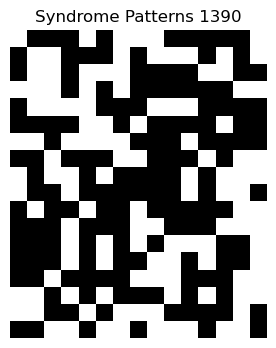

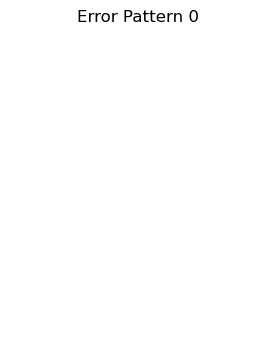

In [26]:
%timeit
error_rate = 0.3
beta = math.log((3+error_rate)/error_rate)/3
x = lattice_space(18, 15)
logicals = logical_operators(x)
lattice = logicals[3].copy()
energy_hist = []
time_list = []
random.seed(1)
# lattice = monte_carlo_error(lattice, 2, error_rate)
truncated = False
step = 0
error_patterns = []
syndromes = []
while not truncated:
    # if step % 100 == 0:
    #     print("Step:", step)
    #     print("Energy history:", energy_hist[-10:])
    #     print("lattice", lattice)
    step += 1
    lattice = monte_carlo_error(lattice, 1, error_rate)
    error_patterns.append(lattice.copy())
    # lattice1, C1 = sweeper(lattice)
    # E = optimal_decoder(lattice)
    # C2 = C2_constructor(E, lattice)
    # E_ = (C1 + C2) % 2
    # print(lattice)
    # print(E_)
    # plt.figure(figsize=(4, 4))
    # plt.imshow(lattice, cmap='binary', interpolation='nearest')
    # plt.show()

    # plt.figure(figsize=(4, 4))
    # plt.imshow(E_, cmap='binary', interpolation='nearest')
    # plt.show()
    # lattice = bkl(lattice, beta, 1, energy_hist, error_rate)
    
    truncated = not logical_checks(lattice, 3)

step

for pattern in error_patterns:
    syndromes.append(syndrome_detector(pattern))

mem_time = sum(time_list)
print("Total time:", mem_time)
print(step)
# print(time_list)
from matplotlib.animation import FuncAnimation, PillowWriter

# Assume error_patterns is defined as a list/array of 2D patterns
fig, ax = plt.subplots(figsize=(4, 4))

def update(frame):
    ax.clear()
    ax.imshow(syndromes[frame], cmap='binary', interpolation='nearest')
    ax.set_title(f"Syndrome Patterns {frame}", fontsize=12)
    ax.axis('off')

ani = FuncAnimation(fig, update, frames=len(syndromes), interval=100, repeat=True)

# To display inline in a Jupyter notebook:
from IPython.display import HTML
HTML(ani.to_jshtml())

# To save as a GIF file:
ani.save('syndrom_patterns1.gif', writer=PillowWriter(fps=3))

from matplotlib.animation import FuncAnimation, PillowWriter

# Assume error_patterns is defined as a list/array of 2D patterns
fig, ax = plt.subplots(figsize=(4, 4))

def update(frame):
    ax.clear()
    ax.imshow(error_patterns[frame], cmap='binary', interpolation='nearest')
    ax.set_title(f"Error Pattern {frame}", fontsize=12)
    ax.axis('off')

ani = FuncAnimation(fig, update, frames=len(error_patterns), interval=100, repeat=True)

# To display inline in a Jupyter notebook:
from IPython.display import HTML
HTML(ani.to_jshtml())

# To save as a GIF file:
ani.save('error_patterns1.gif', writer=PillowWriter(fps=3))

# for pattern in error_patterns:
#     plt.figure(figsize=(4, 4))
#     plt.imshow(pattern, cmap='binary', interpolation='nearest')
#     plt.title("Error Pattern")
#     plt.show()
# for syndrome in syndromes:
#     plt.figure(figsize=(4, 4))
#     plt.imshow(syndrome, cmap='binary', interpolation='nearest')
#     plt.title("Syndrome")
#     plt.show()




In [7]:
def nearest_cluster(e, error_patterns_, clusters, cluster_index):
    error_patterns = error_patterns_.copy()
    # clusters = defaultdict(list)
    # cluster_index = 0
    truncate = True
    if e + [0, 1] in error_patterns:
        clusters[cluster_index].append(e+ [0, 1])
        error_patterns.remove(e+ [0, 1])
        truncate = False
    elif e + [1, 0] in error_patterns:
        clusters[cluster_index].append(e + [1, 0])
        error_patterns.remove(e + [1, 0])
        truncate = False
    elif e + [1, 1] in error_patterns:
        clusters[cluster_index].append(e + [1, 1])
        error_patterns.remove(e + [1, 1])
        truncate = False
    elif e + [0, -1] in error_patterns:
        clusters[cluster_index].append(e+ [0, -1])
        error_patterns.remove(e+ [0, -1])
        truncate = False
    elif e + [-1, 0] in error_patterns:
        clusters[cluster_index].append(e + [-1, 0])
        error_patterns.remove(e + [-1, 0])
        truncate = False
    elif e + [-1, -1] in error_patterns:
        clusters[cluster_index].append(e + [-1, -1])
        error_patterns.remove(e + [-1, -1])
        truncate = False




from collections import defaultdict, Counter
def error_clustering(error_patterns_:list):
    error_patterns = error_patterns_.copy()
    H = error_patterns.shape[0]
    L = error_patterns.shape[1]
    positions = list(zip(*np.where(error_patterns == 1)))

    clusters = defaultdict(list)
    cluster_index = 0
    for e in positions:
        if any(e in cluster for cluster in clusters.values()):
            key = next(k for k, v in clusters.items() if e in v)
            if ((e[0]+0) % H , (e[1] + 1)% L) in positions and not any(((e[0]+0) % H , (e[1] + 1)% L) in cluster for cluster in clusters.values()):
                clusters[key].append(((e[0]+0) % H , (e[1] + 1)% L))
                
            if ((e[0]+1) % H , (e[1] + 0)% L) in positions and not any(((e[0]+1) % H , (e[1] + 0)% L) in cluster for cluster in clusters.values()):
                clusters[key].append(((e[0]+1) % H , (e[1] + 0)% L))
                
            if ((e[0]+1) % H , (e[1] + 1)% L) in positions and not any(((e[0]+1) % H , (e[1] + 1)% L) in cluster for cluster in clusters.values()):
                clusters[key].append(((e[0]+1) % H , (e[1] + 1)% L))
               
            if ((e[0]+0) % H , (e[1] - 1)% L) in positions and not any(((e[0]+0) % H , (e[1] - 1)% L) in cluster for cluster in clusters.values()):
                clusters[key].append(((e[0]+0) % H , (e[1] - 1)% L))
                
            if ((e[0]-1) % H , (e[1] + 0)% L) in positions and not any(((e[0] -1) % H , (e[1] + 0)% L) in cluster for cluster in clusters.values()):
                clusters[key].append(((e[0]-1) % H , (e[1] + 0)% L))
                
            if ((e[0]-1) % H , (e[1] - 1)% L) in positions and not any(((e[0]-1) % H , (e[1] - 1)% L) in cluster for cluster in clusters.values()):
                clusters[key].append(((e[0]-1) % H , (e[1] - 1)% L))
                

        else:
            clusters[cluster_index].append(e) 
            if ((e[0]+0) % H , (e[1] + 1)% L) in positions and not any(((e[0]+0) % H , (e[1] + 1)% L) in cluster for cluster in clusters.values()):
                clusters[cluster_index].append(((e[0]+0) % H , (e[1] + 1)% L))
                
            if ((e[0]+1) % H , (e[1] + 0)% L) in positions and not any(((e[0]+1) % H , (e[1] + 0)% L) in cluster for cluster in clusters.values()):
                clusters[cluster_index].append(((e[0]+1) % H , (e[1] + 0)% L))
                
            if ((e[0]+1) % H , (e[1] + 1)% L) in positions and not any(((e[0]+1) % H , (e[1] + 1)% L) in cluster for cluster in clusters.values()):
                clusters[cluster_index].append(((e[0]+1) % H , (e[1] + 1)% L))
               
            if ((e[0]+0) % H , (e[1] - 1)% L) in positions and not any(((e[0]+0) % H , (e[1] - 1)% L) in cluster for cluster in clusters.values()):
                clusters[cluster_index].append(((e[0]+0) % H , (e[1] - 1)% L))
                
            if ((e[0]-1) % H , (e[1] + 0)% L) in positions and not any(((e[0] -1) % H , (e[1] + 0)% L) in cluster for cluster in clusters.values()):
                clusters[cluster_index].append(((e[0]-1) % H , (e[1] + 0)% L))
                
            if ((e[0]-1) % H , (e[1] - 1)% L) in positions and not any(((e[0]-1) % H , (e[1] - 1)% L) in cluster for cluster in clusters.values()):
                clusters[cluster_index].append(((e[0]-1) % H , (e[1] - 1)% L))
            cluster_index += 1

    return clusters

            
            
            

In [8]:
def error_clustering(error_patterns):
    H, L = error_patterns.shape
    positions = list(zip(*np.where(error_patterns == 1)))

    # 8‐connectivity deltas
    directions = [(-1,-1),(-1,0),
                  ( 0,-1),        (0,1),
                  (1,0), (1,1)]

    clusters = {}            # key -> list of coords
    next_idx = 0

    for e in positions:
        # build all 8 neighbors of e (with wrap)
        neighs = [((e[0]+dx) % H, (e[1]+dy) % L)
                  for dx,dy in directions]

        # find which clusters have ANY neighbor of e
        touching = [k for k, members in clusters.items()
                        if any(n in members for n in neighs)]

        if touching:
            # join the first one…
            base = touching[0]
            clusters[base].append(e)

            # —and if e touches multiple clusters, merge them now
            for other in touching[1:]:
                clusters[base].extend(clusters.pop(other))

        else:
            # e touches none → start a brand-new cluster
            clusters[next_idx] = [e]
            next_idx += 1

    return clusters

def energy_map(clusters, error_patterns):
    """
    Compute the energy map of clusters.
    """
    energy_dict = defaultdict(float)
    patterns = np.zeros_like(error_patterns, dtype=int)
    for key, cluster in clusters.items():
        for e in cluster:
            patterns[e] = 1
        energy_dict[key] = energy(patterns)
    return energy_dict


In [12]:
error_rate = 0.0001
beta = math.log((3+error_rate)/error_rate)/3
x = lattice_space(12, 9)
logicals = logical_operators(x)
logical = 0
lattice = logicals[logical].copy()
energy_hist = []
time_list = []
random.seed(100)
# lattice = monte_carlo_error(lattice, 2, error_rate)
truncated = False
step = 0
error_patterns = []
syndromes = []
while not truncated:
    # if step % 100 == 0:
    #     print("Step:", step)
    #     print("Energy history:", energy_hist[-10:])
    #     print("lattice", lattice)
    step += 1
    lattice = bkl(lattice,  1, error_rate, energy_hist, time_list)
    error_patterns.append((lattice.copy() +logicals[logical].copy()) % 2)
    
    truncated = not logical_checks(lattice, 0)
# clusters = error_clustering(error_patterns[100])
# print(step)
# print(sum(time_list))

for pattern in error_patterns:
    syndromes.append(syndrome_detector(pattern))

mem_time = sum(time_list)
print("Total time:", mem_time)
print(step)
# print(time_list)
from matplotlib.animation import FuncAnimation, PillowWriter

# Assume error_patterns is defined as a list/array of 2D patterns
fig, ax = plt.subplots(figsize=(4, 4))

def update(frame):
    ax.clear()
    ax.imshow(syndromes[frame], cmap='binary', interpolation='nearest')
    ax.set_title(f"Syndrome Patterns {frame}", fontsize=12)
    ax.axis('off')

ani = FuncAnimation(fig, update, frames=len(syndromes), interval=500, repeat=True)

# # To display inline in a Jupyter notebook:
from IPython.display import HTML
HTML(ani.to_jshtml())

# # To save as a GIF file:
# pick your desired fps
writer = PillowWriter(fps=20)

# save as GIF instead of MP4
ani.save('syndrome_patterns.gif', writer=writer, dpi=10)

# from matplotlib.animation import FuncAnimation, PillowWriter

# # Assume error_patterns is defined as a list/array of 2D patterns
fig, ax = plt.subplots(figsize=(4, 4))

def update(frame):
    ax.clear()
    ax.imshow(error_patterns[frame], cmap='binary', interpolation='nearest')
    ax.set_title(f"Error Pattern {frame}", fontsize=12)
    ax.axis('off')

ani = FuncAnimation(fig, update, frames=len(error_patterns), interval=100, repeat=True)

# # To display inline in a Jupyter notebook:
from IPython.display import HTML
HTML(ani.to_jshtml())

# To save as a GIF file:
# pick your desired fps
writer = PillowWriter(fps=10)

# save as GIF instead of MP4
ani.save('error_patterns.gif', writer=writer, dpi=50)





AttributeError: 'tuple' object has no attribute 'copy'

In [81]:
H = 2
L = 3
error_rate = 0.01
beta = math.log((3+error_rate)/error_rate)/3
x = lattice_space(H, L)
logicals = logical_operators(x)
logical = 3
lattice = logicals[logical].copy()
lattice = monte_carlo_error(lattice, 1, 0.5)
energy_hist = []
time_list = []
time = 1000
random.seed(50)
# lattice = monte_carlo_error(lattice, 1, error_rate)
truncated = False
step = 0
error_patterns = []
syndromes = []
spin_config = []
# while not truncated:
while step <12000:
    # if step % 100 == 0:
    #     print("Step:", step)
    #     print("Energy history:", energy_hist[-10:])
    #     print("lattice", lattice)
    step += 1
    lattice = bkl(lattice,  1, error_rate, energy_hist, time_list)
    spin_config.append(lattice.copy())
    error_patterns.append((lattice.copy()+ logicals[logical].copy()) % 2)
    
    # truncated = not logical_checks(lattice, 0)
    
clusters = error_clustering(error_patterns[time])
print(clusters)
value_lengths = [len(v) for v in clusters.values()]
length_counts = Counter(value_lengths)
energies = energy_map(clusters, error_patterns[time])
lengths = sorted(length_counts)
counts = [length_counts[l] for l in lengths]

# plt.imshow(error_patterns[time], cmap='binary', interpolation='nearest')
# plt.show()

# plt.bar(lengths, counts, width=0.6, color='skyblue', edgecolor='black')
# plt.xlabel('Number of elements in each value (length)')
# plt.ylabel('Number of keys with that value length')
# plt.title('Histogram of Value Lengths in Dictionary')
# plt.xticks(lengths)
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

# fig, ax = plt.subplots()
# sc = ax.scatter(
#     lengths,
#     energies,
#     c=energies,        # color by density
#     cmap='viridis',     # or any other matplotlib colormap
#     s=50,               # marker size
#     edgecolor='k',      # optional black border around markers
# )

# # Add a colorbar to indicate density
# cbar = fig.colorbar(sc, ax=ax)
# cbar.set_label('Density')

# # — labels & styling —
# ax.set_xlabel('Length')
# ax.set_ylabel('Energy')
# ax.set_title('Energy vs Length (colored by density)')
# ax.grid(True, linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.show()




{0: [(np.int64(0), np.int64(2)), (np.int64(1), np.int64(1)), (np.int64(1), np.int64(2))]}


In [45]:
def spin_classify(patterns):
    flat_each = [ [x for row in m for x in row] for m in patterns ]
    keys = []
    for flat in flat_each:
        bitstr = ''.join('1' if b else '0' for b in flat)
        keys.append(bitstr)
    classes = defaultdict(int)
    for key in keys:
        if key not in classes:
            classes[key] += 1
        classes[key] +=1 
    return classes

from itertools import product

def all_binary_matrices(n_rows: int, n_cols: int):
    """
    Yield every n_rows x n_cols matrix with entries in {0,1}, row-major order.
    Each matrix is a list of lists of ints.
    Total count: 2**(n_rows * n_cols).
    """
    for bits in product((0, 1), repeat=n_rows * n_cols):
        yield [list(bits[i*n_cols:(i+1)*n_cols]) for i in range(n_rows)]

In [78]:
energy_microstates = []
microstate = []
for mat in all_binary_matrices(2, 3):
    microstate.append(mat)
    energy_microstates.append(energy(np.array(mat)))
    # print(mat)

In [82]:
# classes = spin_classify(spin_config)
classes = spin_classify(spin_config[1000:])
print (classes)

defaultdict(<class 'int'>, {'001011': 592, '001001': 410, '101011': 290, '111011': 104, '111001': 258, '011001': 507, '011011': 19, '011101': 275, '010101': 110, '110101': 331, '100101': 627, '100111': 326, '000111': 96, '000110': 42, '010110': 533, '011110': 272, '001110': 94, '101110': 298, '101100': 620, '111100': 318, '111101': 107, '110001': 84, '011111': 111, '010010': 391, '110010': 542, '000010': 108, '000000': 385, '010000': 108, '010001': 21, '110011': 274, '010111': 287, '011100': 104, '000001': 112, '000101': 40, '110111': 129, '111110': 104, '111010': 285, '100010': 14, '100001': 34, '001000': 105, '001111': 283, '100011': 95, '100100': 426, '101111': 115, '111000': 94, '011000': 31, '000011': 30, '100000': 90, '110110': 40, '010100': 27, '101010': 83, '001010': 19, '110100': 5, '000100': 120, '110000': 18, '001100': 31, '100110': 11, '101001': 4, '101000': 26, '101101': 27, '010011': 5, '111111': 4, '011010': 7, '001101': 6})


In [60]:
print(len(keys_sorted))
print(energy_microstates)

64
[]


[ 9 15 18 23 29 30 36 39 43 46 51 53 57 58 60]
[[0, 0, 1], [0, 0, 1]]
[[0, 0, 1], [1, 1, 1]]
[[0, 1, 0], [0, 1, 0]]
[[0, 1, 0], [1, 1, 1]]
[[0, 1, 1], [1, 0, 1]]
[[0, 1, 1], [1, 1, 0]]
[[1, 0, 0], [1, 0, 0]]
[[1, 0, 0], [1, 1, 1]]
[[1, 0, 1], [0, 1, 1]]
[[1, 0, 1], [1, 1, 0]]
[[1, 1, 0], [0, 1, 1]]
[[1, 1, 0], [1, 0, 1]]
[[1, 1, 1], [0, 0, 1]]
[[1, 1, 1], [0, 1, 0]]
[[1, 1, 1], [1, 0, 0]]


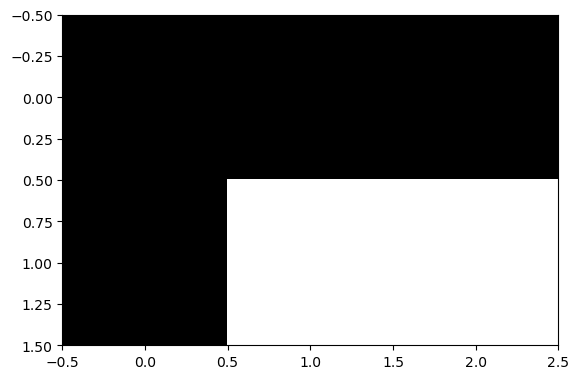

In [74]:
energy_2 = np.where(np.array(energy_microstates) == 2)[0]
print(energy_2)
for i in energy_2:
    print(microstate[i])
    plt.imshow(microstate[i], cmap='binary', interpolation='nearest')

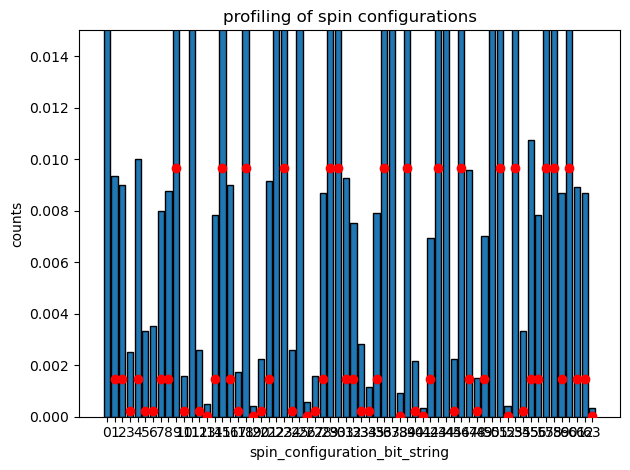

In [83]:
items = sorted(classes.items(), key=lambda kv: kv[0])   # by key (asc)
keys_sorted, vals_by_key = (list(t) for t in zip(*items)) if items else ([], [])

duration = len(spin_config)
amplitudes = np.exp(-beta * np.array(energy_microstates))
P = amplitudes / np.sum(amplitudes)

# plt.scatter(keys_sorted, P, color='red', label='Theoretical Probability', zorder=5)
# plt.bar(keys_sorted, np.array(vals_by_key)/duration, edgecolor="black")
plt.scatter(kk, P, color='red', label='Theoretical Probability', zorder=5)
plt.bar(kk, np.array(vals_by_key)/duration, edgecolor="black")
plt.xlabel("spin_configuration_bit_string")
plt.ylabel("counts")
plt.ylim(0, 0.015)
plt.title("profiling of spin configurations")
plt.tight_layout()
plt.show()

In [69]:
kk = ['0', '1', '2', '3', '4','5', '6', '7', '8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24','25','26','27','28','29','30','31','32','33','34','35','36','37','38','39','40','41','42','43','44','45','46','47','48','49','50','51','52','53','54','55','56','57','58','59','60','61','62','63']

In [37]:
print(keys_sorted)

['000000', '000001', '000010', '000011', '000100', '000101', '000110', '000111', '001000', '001001', '001010', '001011', '001100', '001101', '001110', '001111', '010000', '010001', '010010', '010011', '010100', '010101', '010110', '010111', '011000', '011001', '011010', '011011', '011100', '011101', '011110', '011111', '100000', '100001', '100010', '100011', '100100', '100101', '100110', '100111', '101000', '101001', '101010', '101011', '101100', '101101', '101110', '101111', '110000', '110001', '110010', '110011', '110100', '110101', '110110', '110111', '111000', '111001', '111010', '111011', '111100', '111101', '111110', '111111']


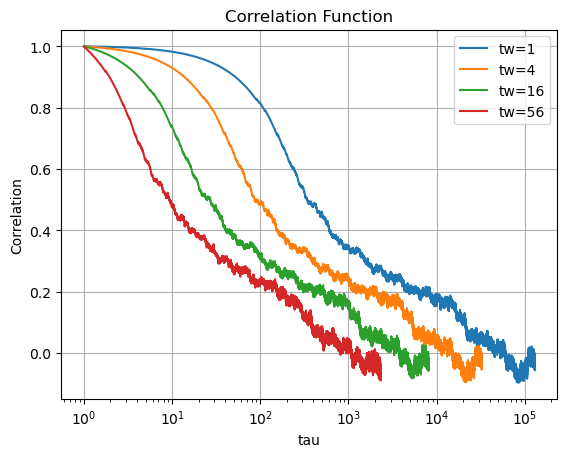

In [21]:
def correlation(spin_config: list, tau:int =4):
    spin_conf = np.array(spin_config.copy())
    spin_conf = 1 - 2 * spin_conf  # Convert to -1, 1
    T, H, L = spin_conf.shape
    N = H * L
    S_T = np.mean(spin_conf)
    # S_T = 1/2
    correlation = []
    correlation = []
    for t in range(tau,T):
        # For each tau, compute the correlation between t0 and t0+tau
        s0 = spin_conf[t]        # shape (H, L)
        st = spin_conf[tau]  # shape (H, L)
        # Correlator: <S(t0) S(t0+tau)> - <S>^2, averaged over sites
        # corr = np.mean(s0 * st) - S_T ** 2
        corr = np.mean((s0 * st)) - np.mean(s0) * np.mean(st) 
        correlation.append(corr)
    return T, correlation

# tau = 16
T0, correlations0 = correlation(spin_config, 1)
T1, correlations1 = correlation(spin_config, 4)
T2, correlations2 = correlation(spin_config, 16)
T3, correlations3 = correlation(spin_config, 56)
time0 = np.arange(1, T0)/1
time1 = np.arange(4, T1)/4
time2 = np.arange(16, T2)/16
time3 = np.arange(56, T3)/56
# time = np.cumsum(time_list[tau:])
# time1 = time/tau
plt.plot(time0, correlations0, label='tw=1')
plt.plot(time1, correlations1, label='tw=4')
plt.plot(time2, correlations2, label='tw=16')
plt.plot(time3, correlations3, label='tw=56')
plt.xlabel('tau')
plt.ylabel('Correlation')
plt.title('Correlation Function')
plt.grid()
plt.legend()
plt.xscale('log')
plt.savefig(f'./results/correlations/correlation_function{H}*{L}.png', dpi=300)
plt.show()


9 6 7670\n 
12 9 11400
15 12 52940
18 15 52500

In [201]:
correlations[1]

np.float64(1.1037037037037036)

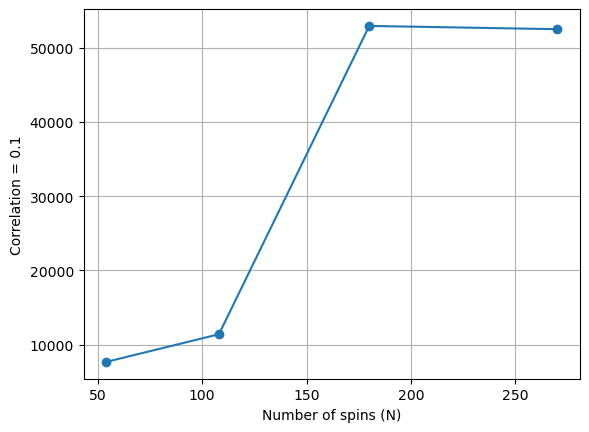

In [194]:
n = [9*6, 12*9, 15*12, 18*15]
corr =[7670,11400, 52940, 52500]
plt.plot(n, corr, marker='o')
plt.xlabel('Number of spins (N)')
plt.ylabel('Correlation = 0.1')
plt.grid()


In [192]:
correlations[52500]

np.float64(0.2)

In [27]:
print(min([0,0,1,1]))

0


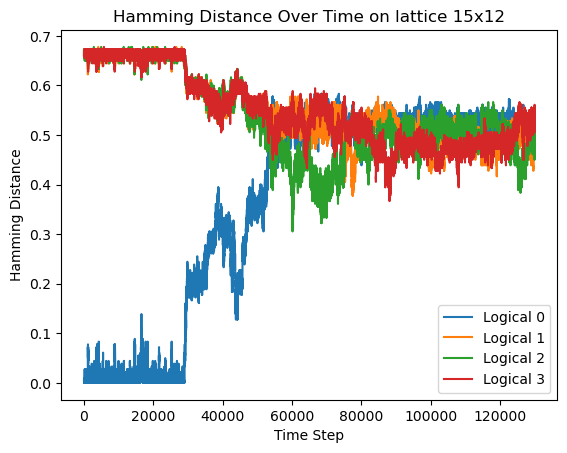

In [47]:
def hamming_distance(spin_config, logicals):
    T = len(spin_config)
    distances = np.zeros((T, len(logicals)), dtype=int)
    for t in range(T):
        for i in range(4):
            spin = spin_config[t]
            logical = logicals[i]
            distance = np.sum((spin + logical) % 2)  # Hamming distance
            distances[t][i] = distance
    return T, distances

T, hamming_distances = hamming_distance(spin_config, logicals)
for i in range(4):
    plt.plot(np.arange(T), hamming_distances[:, i]/(15*12), label=f'Logical {i}')
plt.xlabel('Time Step')
plt.ylabel('Hamming Distance')
plt.title(f'Hamming Distance Over Time on lattice {15}x{12}')
plt.legend()
plt.show()


In [21]:
for t in times:
    print(energy_hist[t])

3.0
5.0
1.0
3.0
3.0
3.0
3.0
1.0
5.0
1.0
3.0
3.0


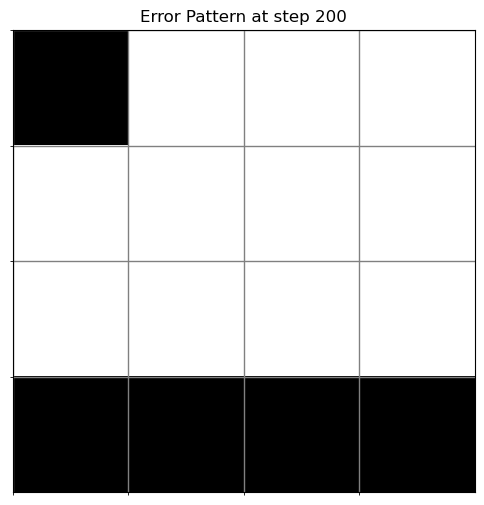

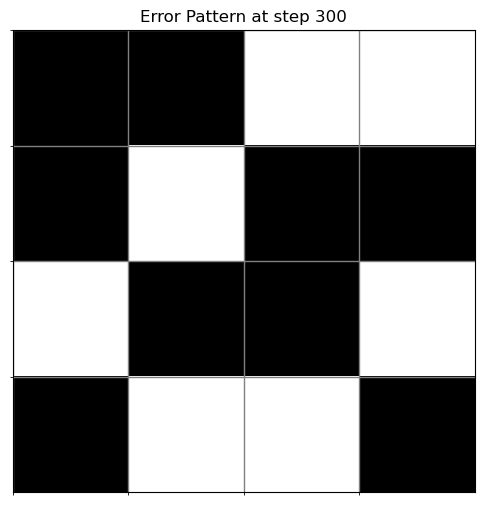

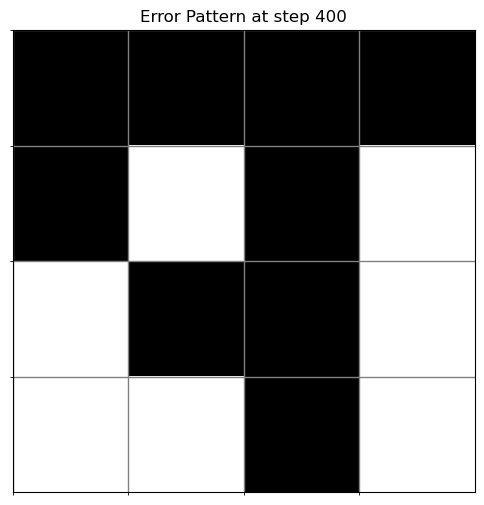

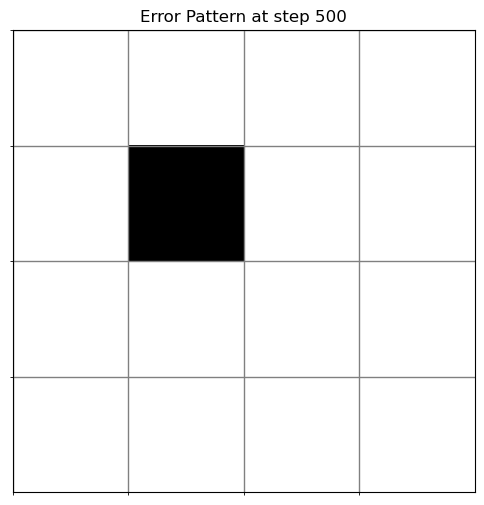

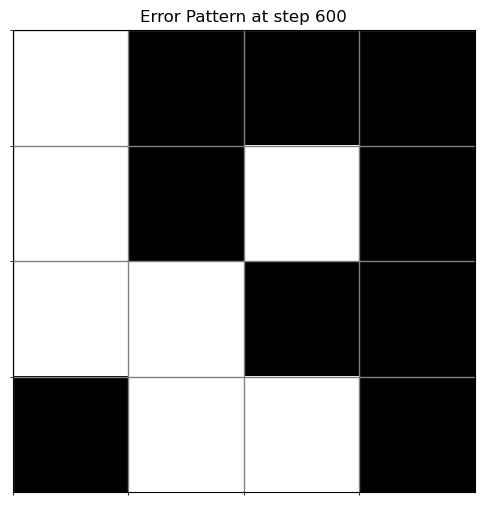

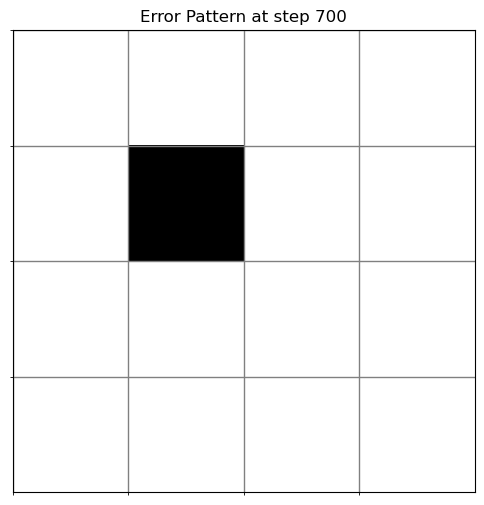

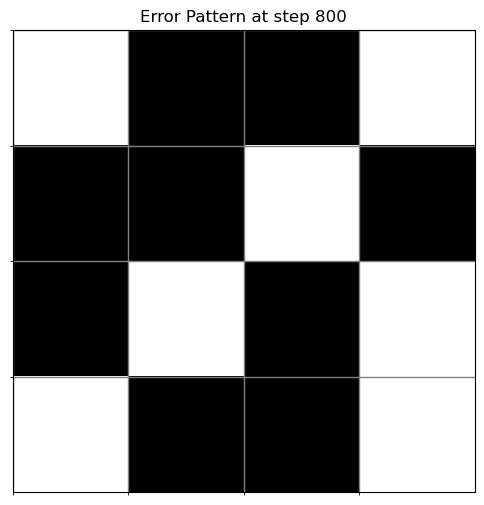

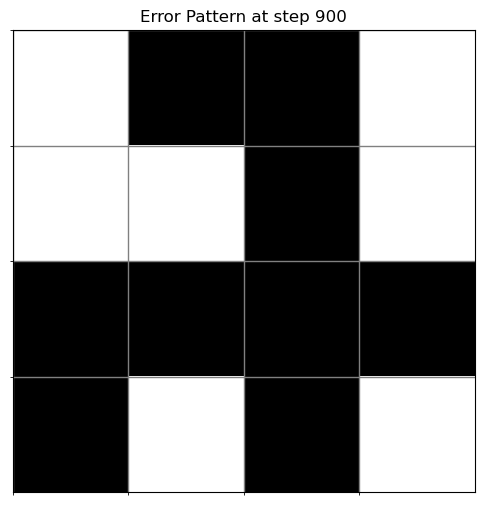

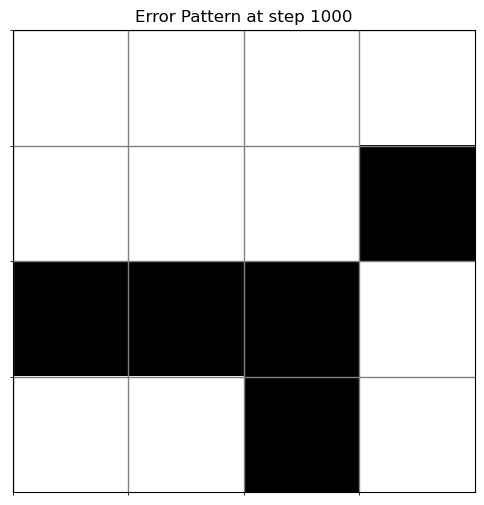

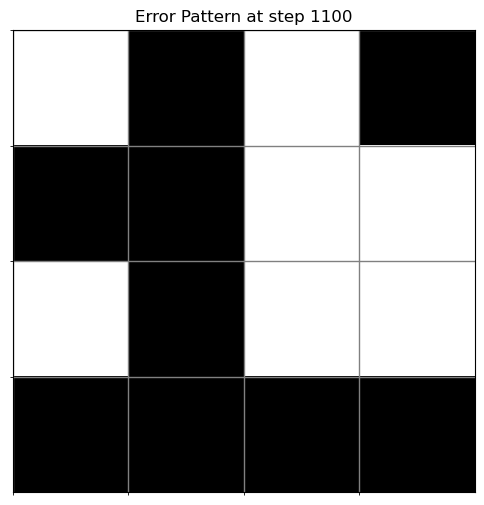

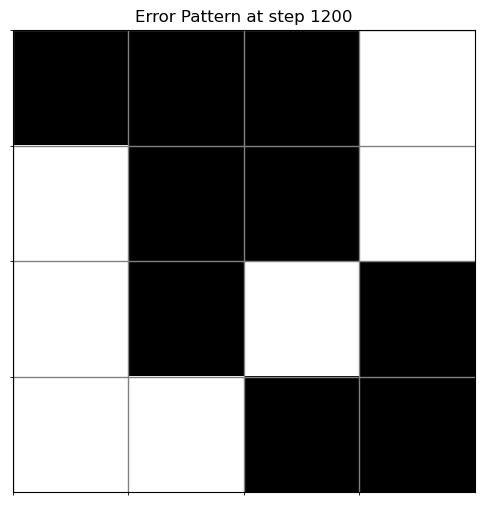

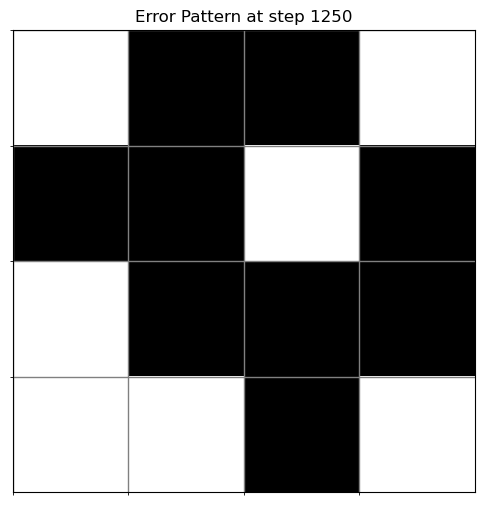

In [22]:
# times = [28000, 28500, 29000, 29500, 30000, 32000, 48000, 49000, 50000, 51000, 52000,53000 ]
times = [200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1250]

# for time in times:
#     clusters = error_clustering(error_patterns[time])
#     print(clusters)
#     value_lengths = [len(v) for v in clusters.values()]
#     length_counts = Counter(value_lengths)
#     energies = energy_map(clusters, error_patterns[time])
#     energies = energies.values()
#     triples = list(zip(value_lengths, length_counts, energies))
#     triples_sorted = sorted(triples, key=lambda t: t[0])
#     lengths_s, counts_s, energies_s = zip(*triples_sorted)
#     plt.imshow(error_patterns[time], cmap='binary', interpolation='nearest')
#     plt.title(f"Error Pattern at step {time}")
#     plt.show()

error = spin_config[-1]  
Es = []
nrows, ncols = error.shape
for time in times:
    checker = (np.indices((nrows, ncols)).sum(axis=0) % 2)

    # clusters = error_clustering(error_patterns[time])
    # energies = energy_map(clusters, error_patterns[time])
    # Es.append(energies.values())


    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(
        checker,
        cmap='Greys',
        interpolation='none',
        alpha=0.3,
        extent=[-0.5, ncols-0.5, nrows-0.5, -0.5]
    )

    ax.imshow(
        error_patterns[time],
        cmap='binary',
        interpolation='none',
        extent=[-0.5, ncols-0.5, nrows-0.5, -0.5]
    )
    ax.set_xticks(np.arange(ncols)-0.5, minor=True)
    ax.set_yticks(np.arange(nrows)-0.5, minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=1)

    # clean up axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Error Pattern at step {time}')
    plt.show()

# plt.bar(lengths, counts, width=0.6, color='skyblue', edgecolor='black')
# plt.xlabel('Number of elements in each value (length)')
# plt.ylabel('Number of keys with that value length')
# plt.title('Histogram of Value Lengths in Dictionary')
# plt.xticks(lengths)
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

# fig, ax = plt.subplots()
# sc = ax.scatter(
#     lengths_s,
#     energies_s,
#     c=counts_s,        # color by density
#     cmap='viridis',     # or any other matplotlib colormap
#     s=50,               # marker size
#     edgecolor='k',      # optional black border around markers
# )

# # — colorbar to show density scale —
# cbar = fig.colorbar(sc, ax=ax)
# cbar.set_label('Counts')

# # — labels & styling —
# ax.set_xlabel('Length')
# ax.set_ylabel('Energy')
# ax.set_title('Energy vs Length (colored by cluster counts)')
# ax.grid(True, linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.show()

In [62]:
print("Energies", Es)
# print(len(Es),len(times))
print(np.vstack((Es, times)))

Energies [dict_values([np.int64(3)]), dict_values([np.int64(3)]), dict_values([np.int64(5)]), dict_values([np.int64(7)]), dict_values([np.int64(3)]), dict_values([np.int64(3)]), dict_values([np.int64(3)]), dict_values([np.int64(3)]), dict_values([np.int64(5)]), dict_values([np.int64(7)]), dict_values([np.int64(7)]), dict_values([np.int64(9)])]
[[dict_values([np.int64(3)]) dict_values([np.int64(3)])
  dict_values([np.int64(5)]) dict_values([np.int64(7)])
  dict_values([np.int64(3)]) dict_values([np.int64(3)])
  dict_values([np.int64(3)]) dict_values([np.int64(3)])
  dict_values([np.int64(5)]) dict_values([np.int64(7)])
  dict_values([np.int64(7)]) dict_values([np.int64(9)])]
 [28000 28500 29000 29500 30000 32000 48000 49000 50000 51000 52000 53000]]


In [ ]:
error_rate = 0.0001
beta = math.log((3+error_rate)/error_rate)/3
x = lattice_space(18, 15)
logicals = logical_operators(x)
lattice = logicals[0].copy()
energy_hist = []
time_list = []
time = 1000
random.seed(500)
# lattice = monte_carlo_error(lattice, 2, error_rate)
truncated = False
step = 0
error_patterns = []
syndromes = []
while not truncated:
    # if step % 100 == 0:
    #     print("Step:", step)
    #     print("Energy history:", energy_hist[-10:])
    #     print("lattice", lattice)
    step += 1
    lattice = monte_carlo_error(lattice,  1, error_rate)
    error_patterns.append((lattice.copy()+ logicals[0].copy()) % 2)
    
    truncated = not logical_checks(lattice, 0)
clusters = error_clustering(error_patterns[time])
print(clusters)
value_lengths = [len(v) for v in clusters.values()]
length_counts = Counter(value_lengths)
energies = energy_map(clusters, error_patterns[time])
lengths = sorted(length_counts)
counts = [length_counts[l] for l in lengths]

plt.imshow(error_patterns[time], cmap='binary', interpolation='nearest')
plt.show()

# plt.bar(lengths, counts, width=0.6, color='skyblue', edgecolor='black')
# plt.xlabel('Number of elements in each value (length)')
# plt.ylabel('Number of keys with that value length')
# plt.title('Histogram of Value Lengths in Dictionary')
# plt.xticks(lengths)
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

fig, ax = plt.subplots()
sc = ax.scatter(
    lengths,
    energies,
    c=energies,        # color by density
    cmap='viridis',     # or any other matplotlib colormap
    s=50,               # marker size
    edgecolor='k',      # optional black border around markers
)

# — colorbar to show density scale —
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Density')

# — labels & styling —
ax.set_xlabel('Length')
ax.set_ylabel('Energy')
ax.set_title('Energy vs Length (colored by density)')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()




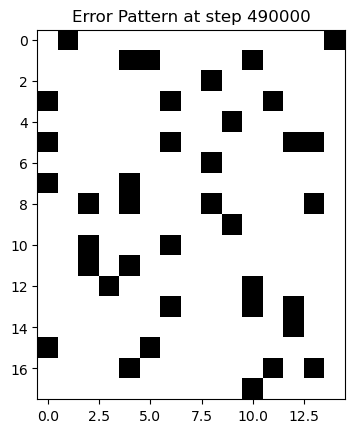

{0: [(np.int64(0), np.int64(1))], 1: [(np.int64(0), np.int64(14))], 2: [(np.int64(1), np.int64(4)), (np.int64(1), np.int64(5))], 3: [(np.int64(1), np.int64(10))], 4: [(np.int64(2), np.int64(8))], 5: [(np.int64(3), np.int64(0))], 6: [(np.int64(3), np.int64(6))], 7: [(np.int64(3), np.int64(11))], 8: [(np.int64(4), np.int64(9))], 9: [(np.int64(5), np.int64(0))], 10: [(np.int64(5), np.int64(6))], 11: [(np.int64(5), np.int64(12)), (np.int64(5), np.int64(13))], 12: [(np.int64(6), np.int64(8))], 13: [(np.int64(7), np.int64(0))], 14: [(np.int64(7), np.int64(4)), (np.int64(8), np.int64(4))], 15: [(np.int64(8), np.int64(2))], 16: [(np.int64(8), np.int64(8)), (np.int64(9), np.int64(9))], 17: [(np.int64(8), np.int64(13))], 18: [(np.int64(10), np.int64(2)), (np.int64(11), np.int64(2)), (np.int64(12), np.int64(3))], 19: [(np.int64(10), np.int64(6))], 20: [(np.int64(11), np.int64(4))], 21: [(np.int64(12), np.int64(10)), (np.int64(13), np.int64(10))], 22: [(np.int64(13), np.int64(6))], 23: [(np.int64(

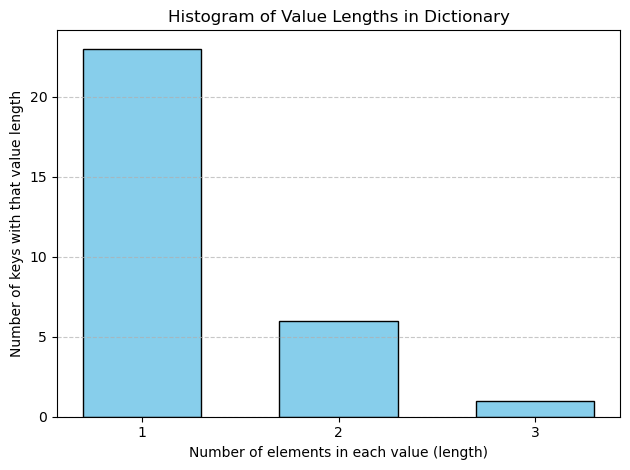

In [283]:
time = 490000
plt.imshow(error_patterns[time], cmap='binary', interpolation='nearest')
plt.title(f"Error Pattern at step {time}")
plt.show()

clusters = error_clustering(error_patterns[time])
print(clusters)
value_lengths = [len(v) for v in clusters.values()]
length_counts = Counter(value_lengths)
energies = energy_map(clusters, error_patterns[time])
lengths = sorted(length_counts)
counts = [length_counts[l] for l in lengths]



plt.bar(lengths, counts, width=0.6, color='skyblue', edgecolor='black')
plt.xlabel('Number of elements in each value (length)')
plt.ylabel('Number of keys with that value length')
plt.title('Histogram of Value Lengths in Dictionary')
plt.xticks(lengths)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Total time: 626452.6435197389


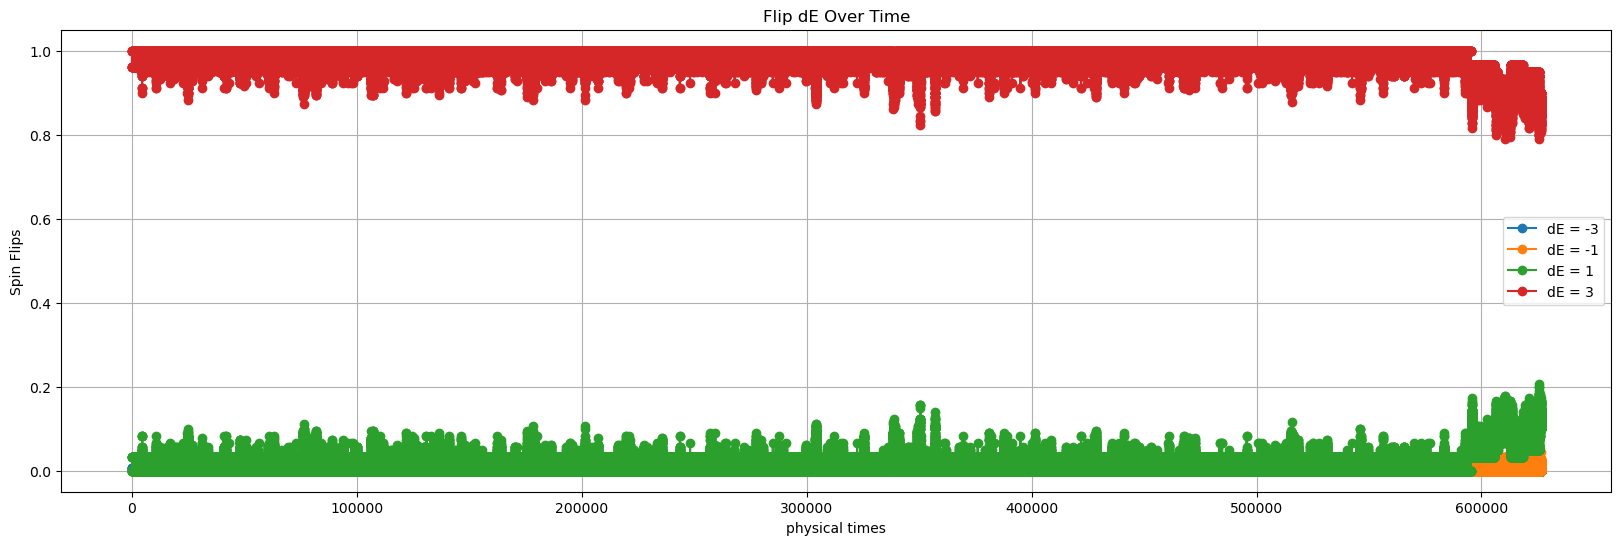

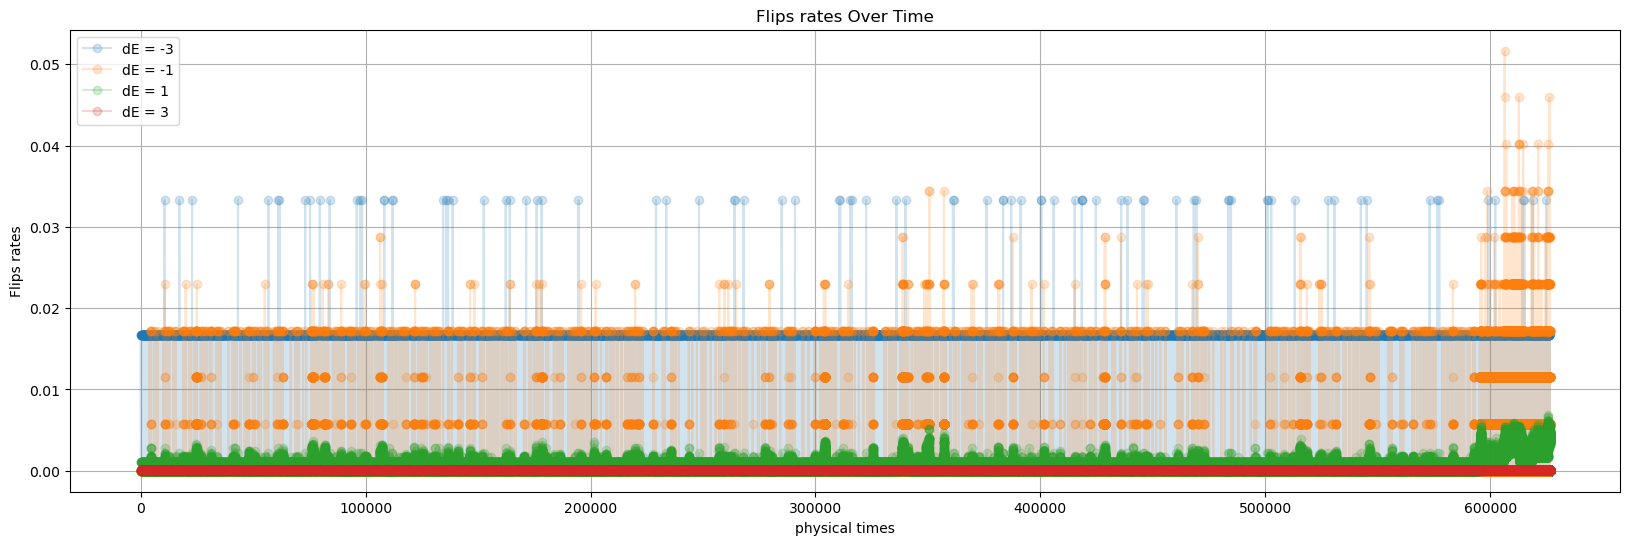

In [41]:

error_rate = 0.0001
beta = math.log((3+error_rate)/error_rate)/3
H = 15
L =12
N = H* L
x = lattice_space(H, L)
logical =0
logicals = logical_operators(x)
lattice = logicals[logical].copy()
energy_hist = []
time_list = []
spin_list =[]
random.seed(500)
# lattice = monte_carlo_error(lattice, 2, error_rate)
truncated = False
step = 0
# error_patterns = []
syndromes = []
nw = []
sw =[]
mag_list = []
while not truncated:
    step += 1
    lattice = bkl(lattice, 1,  error_rate, energy_hist, time_list, spin_list, nw, sw, correction=True)
    # error_patterns.append(lattice.copy())
    mag_list.append(np.sum(lattice) / N)
    
    if step % 10 ==0:
        truncated = not logical_checks(lattice, logical)
# plt.plot(np.arange(step), spin_list, marker='o', linestyle='-', color='b')
# plt.plot(np.cumsum(time_list), spin_list, marker='o', linestyle='-', color='b')
print("Total time:", sum(time_list))
plt.figure(figsize=(20, 6))   
plt.plot(np.cumsum(time_list), np.array([row[0] for row in nw])/N, marker='o', linestyle='-', label='dE = -3')
plt.plot(np.cumsum(time_list), np.array([row[1] for row in nw])/N, marker='o', linestyle='-', label='dE = -1')
plt.plot(np.cumsum(time_list), np.array([row[2] for row in nw])/N, marker='o', linestyle='-', label='dE = 1')
plt.plot(np.cumsum(time_list), np.array([row[3] for row in nw])/N, marker='o', linestyle='-', label='dE = 3')
# plt.hist(spin_list, bins=4, color='blue', alpha=0.7,)
plt.xlabel('physical times')
plt.ylabel('Spin Flips')
plt.title('Flip dE Over Time')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(20, 6))   
plt.plot(np.cumsum(time_list), np.array([row[0] for row in sw])/N, marker='o', linestyle='-', label='dE = -3', alpha =0.2)
plt.plot(np.cumsum(time_list), np.array([row[1] for row in sw])/N, marker='o', linestyle='-', label='dE = -1', alpha =0.2)
plt.plot(np.cumsum(time_list), np.array([row[2] for row in sw])/N, marker='o', linestyle='-', label='dE = 1', alpha =0.2)
plt.plot(np.cumsum(time_list), np.array([row[3] for row in sw])/N, marker='o', linestyle='-', label='dE = 3', alpha =0.2)
# plt.hist(spin_list, bins=4, color='blue', alpha=0.7,)
plt.xlabel('physical times')
plt.ylabel('Flips rates')
plt.title('Flips rates Over Time')
plt.legend()
plt.grid()
plt.show()

# plt.figure(figsize=(20, 6))
# # plt.plot(np.arange(step), spin_list, marker='o', linestyle='-', color='b')
# plt.hist(spin_list, bins=4, color='blue', alpha=0.7,density= True)
# plt.xlabel('Steps')
# plt.ylabel('Spin Flips')
# plt.title('Spin Flips Over Time')
# plt.grid()
# plt.show()

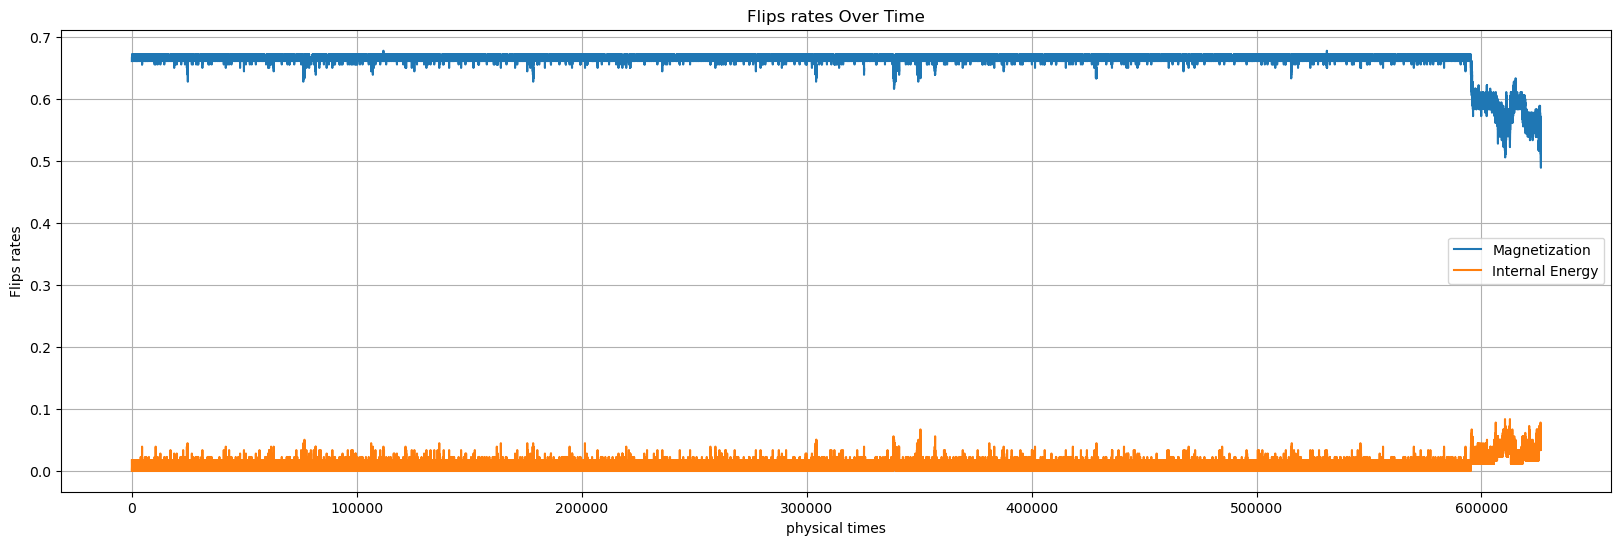

In [42]:
plt.figure(figsize=(20, 6))   
time_list_full_s1 = np.cumsum(time_list)
mag_re_s1 =(+1/2 -np.exp(-2*error_rate*time_list_full_s1)/2)*N
plt.plot(np.cumsum(time_list), np.array(mag_list),  linestyle='-', label='Magnetization')
plt.plot(np.cumsum(time_list), np.array(energy_hist)/N,  linestyle='-', label='Internal Energy')
# plt.plot(np.cumsum(time_list), mag_re_s1, linestyle='-', label='Reconstructed Magnetization')
# plt.plot(np.cumsum(time_list), np.array([row[0] for row in sw])/N, marker='o', linestyle='-', label='dE = -3', alpha =0.2)
# plt.plot(np.cumsum(time_list), np.array([row[1] for row in sw])/N, marker='o', linestyle='-', label='dE = -1', alpha =0.2)
# plt.plot(np.cumsum(time_list), np.array([row[2] for row in sw])/N, marker='o', linestyle='-', label='dE = 1', alpha =0.2)
# plt.plot(np.cumsum(time_list), np.array([row[3] for row in sw])/N, marker='o', linestyle='-', label='dE = 3', alpha =0.2)
# plt.hist(spin_list, bins=4, color='blue', alpha=0.7,)
plt.xlabel('physical times')
plt.ylabel('Flips rates')
plt.title('Flips rates Over Time')
plt.legend()
plt.grid()
plt.show()

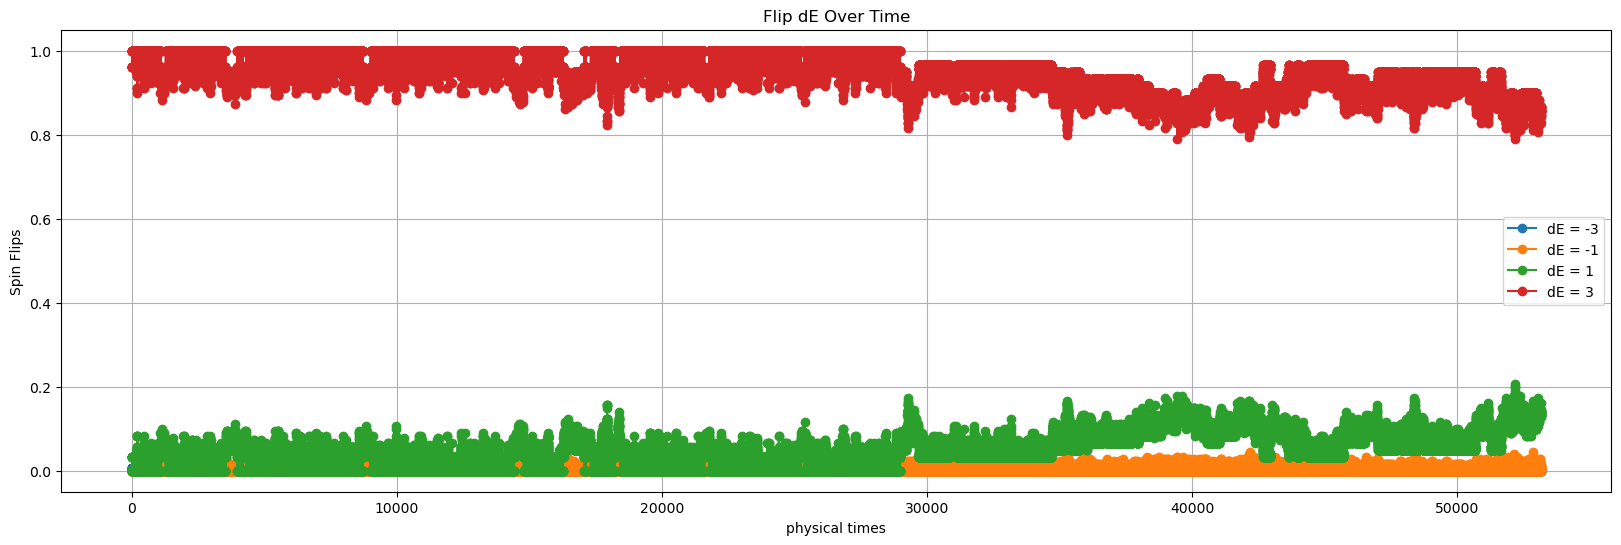

In [43]:
plt.figure(figsize=(20, 6))   
plt.plot(np.arange(len(time_list)), np.array([row[0] for row in nw])/N, marker='o', linestyle='-', label='dE = -3')
plt.plot(np.arange(len(time_list)), np.array([row[1] for row in nw])/N, marker='o', linestyle='-', label='dE = -1')
plt.plot(np.arange(len(time_list)), np.array([row[2] for row in nw])/N, marker='o', linestyle='-', label='dE = 1')
plt.plot(np.arange(len(time_list)), np.array([row[3] for row in nw])/N, marker='o', linestyle='-', label='dE = 3')
# plt.hist(spin_list, bins=4, color='blue', alpha=0.7,)
plt.xlabel('physical times')
plt.ylabel('Spin Flips')
plt.title('Flip dE Over Time')
plt.legend()
plt.grid()
plt.show()

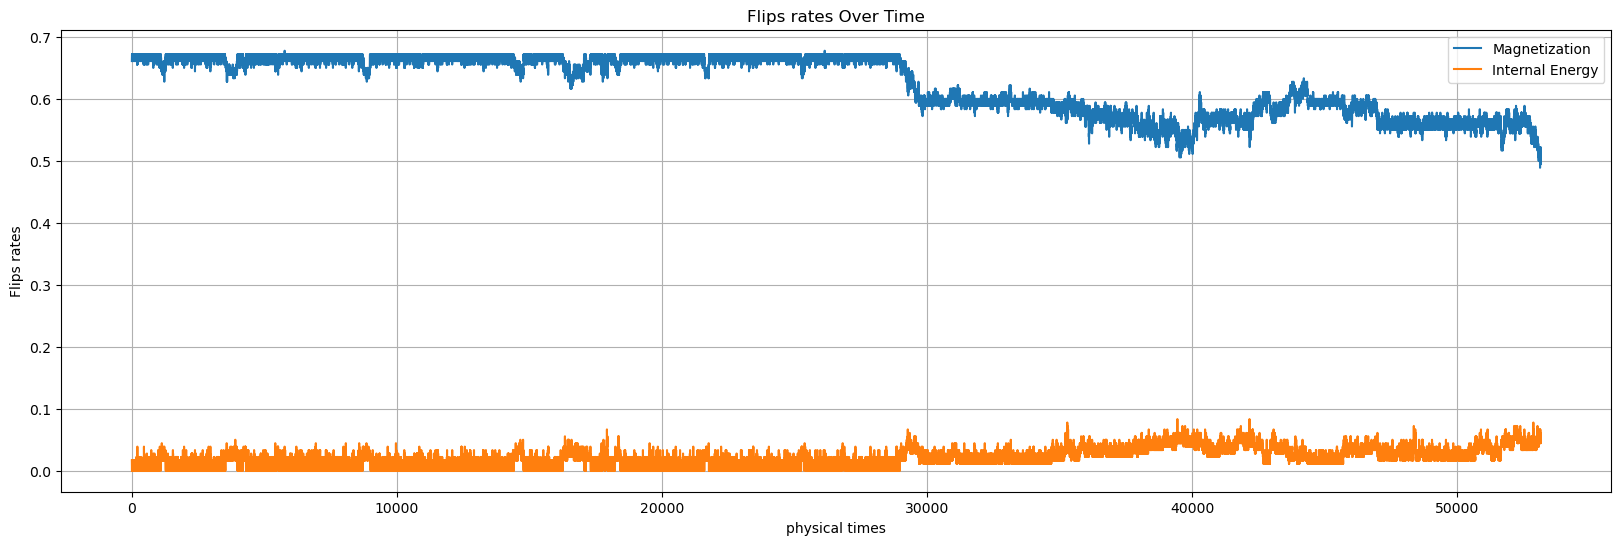

In [44]:
plt.figure(figsize=(20, 6))   
time_list_full_s1 = np.cumsum(time_list)
mag_re_s1 =(+1/2 -np.exp(-2*error_rate*time_list_full_s1)/2)*N
plt.plot(np.arange(len(time_list)), np.array(mag_list),  linestyle='-', label='Magnetization')
plt.plot(np.arange(len(time_list)), np.array(energy_hist)/N,  linestyle='-', label='Internal Energy')
# plt.plot(np.cumsum(time_list), mag_re_s1, linestyle='-', label='Reconstructed Magnetization')
# plt.plot(np.cumsum(time_list), np.array([row[0] for row in sw])/N, marker='o', linestyle='-', label='dE = -3', alpha =0.2)
# plt.plot(np.cumsum(time_list), np.array([row[1] for row in sw])/N, marker='o', linestyle='-', label='dE = -1', alpha =0.2)
# plt.plot(np.cumsum(time_list), np.array([row[2] for row in sw])/N, marker='o', linestyle='-', label='dE = 1', alpha =0.2)
# plt.plot(np.cumsum(time_list), np.array([row[3] for row in sw])/N, marker='o', linestyle='-', label='dE = 3', alpha =0.2)
# plt.hist(spin_list, bins=4, color='blue', alpha=0.7,)
plt.xlabel('physical times')
plt.ylabel('Flips rates')
plt.title('Flips rates Over Time')
plt.legend()
plt.grid()
plt.show()

In [141]:
time_list_full_s1[:14]
# print(energy_hist[-10]/N)
# time_list

array([  3.25058992,   4.53616757,  31.20893093,  31.28462177,
        45.12597526,  45.6842075 ,  48.0883812 ,  48.32780119,
        52.46027532,  52.8137233 ,  61.46192263,  61.48958288,
       123.61628207, 123.69417028])

In [139]:
print(spin_list)
print(time_list)


[np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(1.0), np.float64(1.0), np.float64(-1.0), np.float64(-1.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(1.0), np.float64(-1.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(1.0), np.float64(-1.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np.float64(-3.0), np.float64(3.0), np

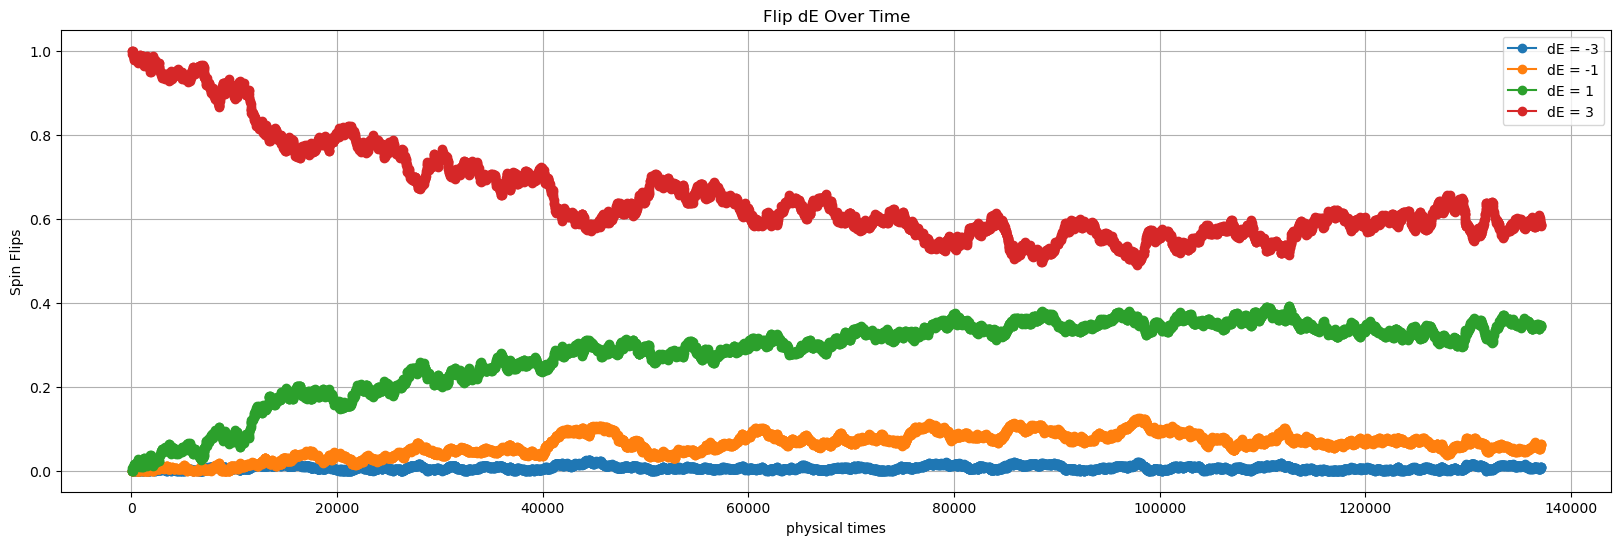

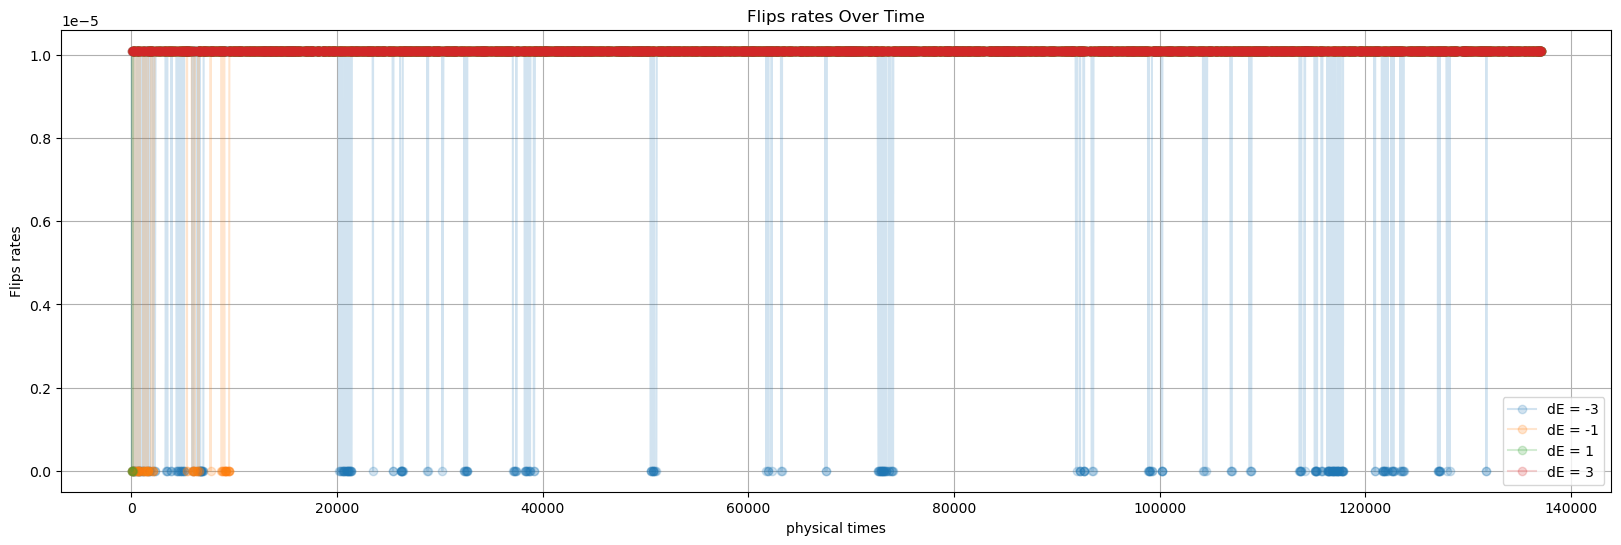

In [6]:

error_rate = 0.01
beta = math.log((3+error_rate)/error_rate)/3
H = 33
L =30
N = H* L
x = lattice_space(H, L)
logical =0
logicals = logical_operators(x)
lattice = logicals[logical].copy()
energy_hist = []
time_list = []
spin_list =[]
random.seed(10)
# lattice = monte_carlo_error(lattice, 2, error_rate)
truncated = False
step = 0
error_patterns = []
syndromes = []
nw = []
sw =[]
while not truncated:
    step += 1
    lattice = bkl(lattice, 1,  error_rate, energy_hist, time_list, spin_list, nw, sw, correction=False)
    error_patterns.append(lattice.copy())
    
    if step % 10 ==0:
        truncated = not logical_checks(lattice, logical)
# plt.plot(np.arange(step), spin_list, marker='o', linestyle='-', color='b')
# plt.plot(np.cumsum(time_list), spin_list, marker='o', linestyle='-', color='b')
plt.figure(figsize=(20, 6))   
plt.plot(np.cumsum(time_list), np.array([row[0] for row in nw])/N, marker='o', linestyle='-', label='dE = -3')
plt.plot(np.cumsum(time_list), np.array([row[1] for row in nw])/N, marker='o', linestyle='-', label='dE = -1')
plt.plot(np.cumsum(time_list), np.array([row[2] for row in nw])/N, marker='o', linestyle='-', label='dE = 1')
plt.plot(np.cumsum(time_list), np.array([row[3] for row in nw])/N, marker='o', linestyle='-', label='dE = 3')
# plt.hist(spin_list, bins=4, color='blue', alpha=0.7,)
plt.xlabel('physical times')
plt.ylabel('Spin Flips')
plt.title('Flip dE Over Time')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(20, 6))   
plt.plot(np.cumsum(time_list), np.array([row[0] for row in sw])/N, marker='o', linestyle='-', label='dE = -3', alpha =0.2)
plt.plot(np.cumsum(time_list), np.array([row[1] for row in sw])/N, marker='o', linestyle='-', label='dE = -1', alpha =0.2)
plt.plot(np.cumsum(time_list), np.array([row[2] for row in sw])/N, marker='o', linestyle='-', label='dE = 1', alpha =0.2)
plt.plot(np.cumsum(time_list), np.array([row[3] for row in sw])/N, marker='o', linestyle='-', label='dE = 3', alpha =0.2)
# plt.hist(spin_list, bins=4, color='blue', alpha=0.7,)
plt.xlabel('physical times')
plt.ylabel('Flips rates')
plt.title('Flips rates Over Time')
plt.legend()
plt.grid()
plt.show()

# plt.figure(figsize=(20, 6))
# # plt.plot(np.arange(step), spin_list, marker='o', linestyle='-', color='b')
# plt.hist(spin_list, bins=4, color='blue', alpha=0.7,density= True)
# plt.xlabel('Steps')
# plt.ylabel('Spin Flips')
# plt.title('Spin Flips Over Time')
# plt.grid()
# plt.show()

In [ ]:
import math
import random
from multiprocessing import Process, Manager

def run_until_truncation(seed: int,
                         error_rate: float,
                         out_list: list):
    """
    Run the lattice‐evolution until logical_checks(lattice) is False.
    Append the final step count (i.e. number of iterations before truncation)
    to out_list.
    """
    # 1) reproducible randomness
    random.seed(seed)

    # 2) parameters
    beta = math.log((3 + error_rate) / error_rate) / 3

    # 3) init lattice
    x = lattice_space(9, 6)
    logicals = logical_operators(x)
    lattice = logicals[3].copy()

    # 4) evolve until logical_checks fails
    step = 0

    truncated = False
    while  not truncated:
        if step % 5 ==0:
            truncated = not logical_checks(lattice)
        step += 1
        lattice = bkl(lattice, 1, [], error_rate, [])

    # 5) record the stopping step
    out_list.append(step)


if __name__ == "__main__":
    error_rate = 1e-4

    # pick as many seeds as you like
    seeds = np.arange(40, dtype=int)

    # a Manager list to collect each run’s stopping step
    manager = Manager()
    stop_steps = manager.list()

    procs = []
    for s in seeds:
        p = Process(
            target=run_until_truncation,
            args=(s, error_rate, stop_steps)
        )
        p.start()
        procs.append(p)

    # wait for all processes to finish
    for p in procs:
        p.join()

    # convert to a normal list and average
    stop_steps = list(stop_steps)
    avg_stop = sum(stop_steps) / len(stop_steps)

    print("Stopping steps for each seed:", stop_steps)
    print(f"Average stopping step over {len(stop_steps)} runs: {avg_stop:.2f}")


In [ ]:
(14, 4602), (148, 2539), (48, 1992), (90, 2746), (177, 777)
(90, 9381), (10, 29600), (3, 11794), (58, 15337), (117, 47358)

ValueError: x and y must be the same size

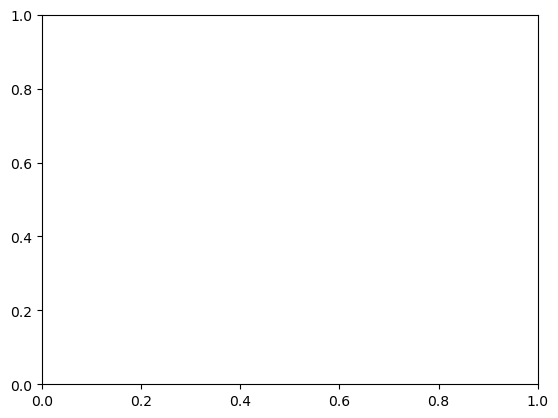

In [51]:
# x = [12*9, 12*9, 12*9, 12*9, 12*9, 12*9]
x1 =[ 12*9, 15*12, 18*15, 21*18, 24*21, 27*24, 30*27]
y1 = [27187, 36462, 70455, 80239, 188794, 457136, 407294]
x1_ref = [109.32560398622097, 218.50574349457767, 365.46958146734687, 543.1329931700369, 1016.3749435701338, 1292.0084393664602, 1633.4098188788598]
y1_ref = [ 93501.10302316841,  281448.4929580337,  490751.27867525874, 701874.4114026949, 1202351.9748568265, 1267882.9386205622, 1126591.86718368]

y = [29600, 28484, 14181, 131877, 297727, 483877]
plt.scatter(x1, y_1, label='BKL', color='blue')
plt.scatter(x1_ref, y1_ref, label='Reference', color='red')
plt.xlabel('N')
plt.ylabel('Time ')
plt.xscale('log')
plt.yscale('log')
plt.title('BKL Algorithm Performance')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
5626154/483877

11.627239980408245

In [37]:
1694633.4920124558/297727

5.691903965755393

In [41]:
282544.3852565626/38245

7.3877470324633965

In [45]:
337643.0176307265/33222

10.163235736280974